# EDA — Parados

---
## 0. Configuración del Dataset

In [1]:
# ============================================================
# CONFIGURACIÓN: PARADOS
# ============================================================

DATASET_CONFIG = {
    'nombre': 'parados',
    'archivo': 'parados_sexo_edad.csv',
    'frecuencia_original': 'trimestral',
    'col_fecha': 'fecha',
    'variable_principal': 'parados_ambos_sexos_total',
    'variables_desgloses': [
        'parados_hombres_total',
        'parados_mujeres_total',
        'parados_ambos_sexos_menos_de_25',
        'parados_ambos_sexos_25_o_mas',
    ],
    'columnas_numericas': [
        'parados_ambos_sexos_total',
        'parados_hombres_total',
        'parados_mujeres_total',
        'parados_ambos_sexos_menos_de_25',
        'parados_ambos_sexos_25_o_mas',
        'parados_hombres_menos_de_25',
        'parados_hombres_25_o_mas',
        'parados_mujeres_menos_de_25',
        'parados_mujeres_25_o_mas',
        'tasa_paro_ambos_sexos_total',
        'tasa_paro_ambos_sexos_25_o_mas',
        'tasa_paro_ambos_sexos_menos_de_25',
        'tasa_paro_hombres_total',
        'tasa_paro_hombres_25_o_mas',
        'tasa_paro_hombres_menos_de_25',
        'tasa_paro_mujeres_total',
        'tasa_paro_mujeres_25_o_mas',
        'tasa_paro_mujeres_menos_de_25',
        'brecha_genero_paro',
        'tasa_paro_juvenil_ratio',
    ],
    'unidades': 'miles de personas',
    'notas': 'EPA, INE. Ruptura metodológica en 2002 (enlace por diferencias). Datos trimestrales desde 1976Q3.',
}

VAR_PRINCIPAL = DATASET_CONFIG['variable_principal']
NOMBRE        = DATASET_CONFIG['nombre']
UNIDADES      = DATASET_CONFIG['unidades']

PERIODO_ESTACIONAL = {
    'trimestral': 4,
    'mensual': 12,
    'diaria': 365,
}[DATASET_CONFIG['frecuencia_original']]

LAGS_ACF = {
    'trimestral': 16,
    'mensual': 36,
    'diaria': 60,
}[DATASET_CONFIG['frecuencia_original']]

print(f'Dataset configurado: {NOMBRE}')
print(f'Variable principal:  {VAR_PRINCIPAL}')
print(f'Frecuencia:          {DATASET_CONFIG["frecuencia_original"]}')
print(f'Periodo estacional:  {PERIODO_ESTACIONAL}')

Dataset configurado: parados
Variable principal:  parados_ambos_sexos_total
Frecuencia:          trimestral
Periodo estacional:  4


---
## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import warnings
from pathlib import Path
from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

RUTA_BASE = Path(r'C:\Users\marco\PycharmProjects\TFM_Marcos\Datasets')

COLOR_PRINCIPAL = '#5E35B1'
COLORES_DESGLOSES = ['#00897B', '#FF7043', '#FFC107', '#1565C0', '#AD1457']

EVENTOS = {
    '1986-01-01': 'Entrada UE',
    '1999-01-01': 'Euro',
    '2008-09-01': 'Crisis\nfinanciera',
    '2012-01-01': 'Crisis\ndeuda',
    '2020-03-01': 'COVID-19',
}
EVENTOS['1994-01-01'] = 'Paro máx\n94'
EVENTOS['2013-03-01'] = 'Paro máx\n13'


---
## 1. Carga y Diagnóstico Básico

In [3]:
ruta = RUTA_BASE / DATASET_CONFIG['archivo']
df = pd.read_csv(ruta)
df[DATASET_CONFIG['col_fecha']] = pd.to_datetime(df[DATASET_CONFIG['col_fecha']])
df = df.set_index(DATASET_CONFIG['col_fecha']).sort_index()

for col in DATASET_CONFIG['columnas_numericas']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Dataset: {NOMBRE}')
print(f'Notas:   {DATASET_CONFIG["notas"]}')
print('=' * 60)
print(f'Shape:          {df.shape}')
print(f'Rango temporal: {df.index.min().date()} a {df.index.max().date()}')
print(f'Observaciones:  {len(df)}')
print(f'Columnas:       {list(df.columns)}')

Dataset: parados
Notas:   EPA, INE. Ruptura metodológica en 2002 (enlace por diferencias). Datos trimestrales desde 1976Q3.
Shape:          (198, 36)
Rango temporal: 1976-07-01 a 2025-10-01
Observaciones:  198
Columnas:       ['año', 'trimestre', 'periodo', 'parados_ambos_sexos_total', 'diferencia_parados_ambos_sexos_total', 'parados_ambos_sexos_menos_de_25', 'diferencia_parados_ambos_sexos_menos_de_25', 'parados_ambos_sexos_25_o_mas', 'diferencia_parados_ambos_sexos_25_o_mas', 'parados_hombres_total', 'diferencia_parados_hombres_total', 'parados_hombres_menos_de_25', 'diferencia_parados_hombres_menos_de_25', 'parados_hombres_25_o_mas', 'diferencia_parados_hombres_25_o_mas', 'parados_mujeres_total', 'diferencia_parados_mujeres_total', 'parados_mujeres_menos_de_25', 'diferencia_parados_mujeres_menos_de_25', 'parados_mujeres_25_o_mas', 'diferencia_parados_mujeres_25_o_mas', 'tasa_paro_juvenil_ratio', 'ratio_paro_juvenil', 'brecha_genero_parados', 'ratio_feminizacion_paro', 'indice_relati

In [4]:
print('Primeras 3 filas:')
display(df.head(3))
print('\nÚltimas 3 filas:')
display(df.tail(3))

Primeras 3 filas:


,año,trimestre,periodo,parados_ambos_sexos_total,diferencia_parados_ambos_sexos_total,parados_ambos_sexos_menos_de_25,diferencia_parados_ambos_sexos_menos_de_25,parados_ambos_sexos_25_o_mas,diferencia_parados_ambos_sexos_25_o_mas,parados_hombres_total,diferencia_parados_hombres_total,parados_hombres_menos_de_25,diferencia_parados_hombres_menos_de_25,parados_hombres_25_o_mas,diferencia_parados_hombres_25_o_mas,parados_mujeres_total,diferencia_parados_mujeres_total,parados_mujeres_menos_de_25,diferencia_parados_mujeres_menos_de_25,parados_mujeres_25_o_mas,diferencia_parados_mujeres_25_o_mas,tasa_paro_juvenil_ratio,ratio_paro_juvenil,brecha_genero_parados,ratio_feminizacion_paro,indice_relativo_paro,tasa_paro_ambos_sexos_total,tasa_paro_ambos_sexos_25_o_mas,tasa_paro_ambos_sexos_menos_de_25,tasa_paro_hombres_total,tasa_paro_hombres_25_o_mas,tasa_paro_hombres_menos_de_25,tasa_paro_mujeres_total,tasa_paro_mujeres_25_o_mas,tasa_paro_mujeres_menos_de_25,brecha_genero_paro
fecha,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1976-07-01,1976,3,1976Q3,589.000,0.000,280.000,0.000,309.000,0.000,406.900,0.000,151.100,0.000,255.800,0.000,182.100,0.000,129.000,0.000,53.200,0.000,3.360,47.538,-224.800,30.917,20.218,4.407,2.935,9.863,4.258,3.211,9.510,4.779,2.078,10.319,0.521
1976-10-01,1976,4,1976Q4,627.772,-0.228,303.872,-0.128,323.900,0.000,441.215,-0.185,166.872,-0.128,274.343,-0.057,186.600,0.000,137.000,0.000,49.699,-0.001,3.465,48.405,-254.615,29.724,21.549,4.721,3.096,10.725,4.636,3.455,10.584,4.937,1.970,10.901,0.300
1977-01-01,1977,1,1977Q1,652.868,-1.232,313.475,-0.625,339.393,-0.507,464.105,-1.095,174.703,-0.597,289.402,-0.498,188.763,-0.137,138.772,-0.228,49.991,-0.009,3.422,48.015,-275.342,28.913,22.410,4.920,3.248,11.115,4.883,3.647,11.133,5.014,1.989,11.093,0.131



Últimas 3 filas:


,año,trimestre,periodo,parados_ambos_sexos_total,diferencia_parados_ambos_sexos_total,parados_ambos_sexos_menos_de_25,diferencia_parados_ambos_sexos_menos_de_25,parados_ambos_sexos_25_o_mas,diferencia_parados_ambos_sexos_25_o_mas,parados_hombres_total,diferencia_parados_hombres_total,parados_hombres_menos_de_25,diferencia_parados_hombres_menos_de_25,parados_hombres_25_o_mas,diferencia_parados_hombres_25_o_mas,parados_mujeres_total,diferencia_parados_mujeres_total,parados_mujeres_menos_de_25,diferencia_parados_mujeres_menos_de_25,parados_mujeres_25_o_mas,diferencia_parados_mujeres_25_o_mas,tasa_paro_juvenil_ratio,ratio_paro_juvenil,brecha_genero_parados,ratio_feminizacion_paro,indice_relativo_paro,tasa_paro_ambos_sexos_total,tasa_paro_ambos_sexos_25_o_mas,tasa_paro_ambos_sexos_menos_de_25,tasa_paro_hombres_total,tasa_paro_hombres_25_o_mas,tasa_paro_hombres_menos_de_25,tasa_paro_mujeres_total,tasa_paro_mujeres_25_o_mas,tasa_paro_mujeres_menos_de_25,brecha_genero_paro
fecha,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-04-01,2025,2,2025Q2,2553.100,NaN,450.600,NaN,2102.500,NaN,1203.000,NaN,232.300,NaN,970.900,NaN,1350.000,NaN,218.400,NaN,1131.800,NaN,2.683,17.649,147.000,52.877,87.637,10.286,9.147,24.538,9.196,8.034,23.305,11.499,10.383,26.012,2.303
2025-07-01,2025,3,2025Q3,2613.200,NaN,504.100,NaN,2109.000,NaN,1180.400,NaN,257.900,NaN,922.500,NaN,1432.800,NaN,246.300,NaN,1186.400,NaN,2.773,19.291,252.400,54.829,89.700,10.453,9.163,25.413,8.966,7.622,24.284,12.107,10.872,26.722,3.141
2025-10-01,2025,4,2025Q4,2477.100,NaN,407.900,NaN,2069.400,NaN,1153.300,NaN,217.900,NaN,935.400,NaN,1323.800,NaN,190.000,NaN,1133.900,NaN,2.576,16.467,170.500,53.442,85.028,9.932,8.932,23.013,8.764,7.670,22.627,11.236,10.335,23.471,2.472


In [5]:
cols_num = DATASET_CONFIG['columnas_numericas']
cols_num = [c for c in cols_num if c in df.columns]

nulos = pd.DataFrame({
    'n_nulos': df[cols_num].isnull().sum(),
    'pct_nulos': df[cols_num].isnull().mean() * 100,
    'primer_valido': [df[c].first_valid_index() for c in cols_num],
    'ultimo_valido': [df[c].last_valid_index() for c in cols_num],
}).round(2)

print('Diagnóstico de valores faltantes:')
display(nulos)

n_dupl = df.index.duplicated().sum()
print(f'\nDuplicados de fecha: {n_dupl}')

Diagnóstico de valores faltantes:


,n_nulos,pct_nulos,primer_valido,ultimo_valido
parados_ambos_sexos_total,0,0.000,1976-07-01,2025-10-01
parados_hombres_total,0,0.000,1976-07-01,2025-10-01
parados_mujeres_total,0,0.000,1976-07-01,2025-10-01
parados_ambos_sexos_menos_de_25,0,0.000,1976-07-01,2025-10-01
parados_ambos_sexos_25_o_mas,0,0.000,1976-07-01,2025-10-01
parados_hombres_menos_de_25,0,0.000,1976-07-01,2025-10-01
parados_hombres_25_o_mas,0,0.000,1976-07-01,2025-10-01
parados_mujeres_menos_de_25,0,0.000,1976-07-01,2025-10-01
parados_mujeres_25_o_mas,0,0.000,1976-07-01,2025-10-01
tasa_paro_ambos_sexos_total,0,0.000,1976-07-01,2025-10-01



Duplicados de fecha: 0


In [6]:
if len(df) > 1:
    diffs = df.index.to_series().diff().dropna()
    print(f'Intervalo mediano entre observaciones: {diffs.median()}')
    print(f'Intervalo mínimo:                      {diffs.min()}')
    print(f'Intervalo máximo:                      {diffs.max()}')

    umbral = diffs.median() * 2
    huecos = diffs[diffs > umbral]
    if len(huecos) > 0:
        print(f'\nHuecos temporales detectados ({len(huecos)}):')
        print(huecos)

Intervalo mediano entre observaciones: 92 days 00:00:00
Intervalo mínimo:                      90 days 00:00:00
Intervalo máximo:                      92 days 00:00:00


---
## 2. Series Temporales

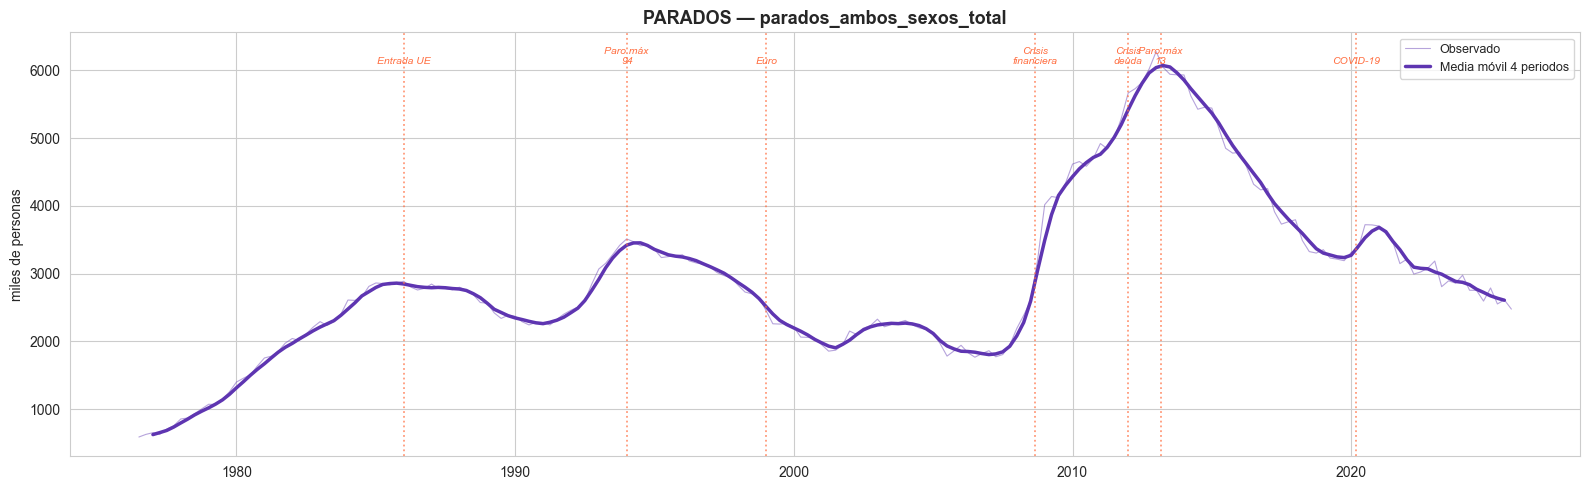

Mín: 589.00  (1976-07-01)
Máx: 6278.20  (2013-01-01)


In [7]:
ventana_mm = PERIODO_ESTACIONAL

fig, ax = plt.subplots(figsize=(16, 5))

y = df[VAR_PRINCIPAL].dropna()
mm = y.rolling(ventana_mm, center=True).mean()

ax.plot(y.index, y, color=COLOR_PRINCIPAL, lw=0.8, alpha=0.45, label='Observado')
ax.plot(y.index, mm, color=COLOR_PRINCIPAL, lw=2.5,
        label=f'Media móvil {ventana_mm} periodos')

y_max = y.max()
for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if y.index.min() <= fecha_ev <= y.index.max():
        ax.axvline(fecha_ev, color='#FF7043', linestyle=':', lw=1.3, alpha=0.7)
        ax.text(fecha_ev, y_max * 0.97, texto,
                ha='center', fontsize=7.5, color='#FF7043', fontstyle='italic')

ax.set_title(f'{NOMBRE.upper()} — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')
ax.set_ylabel(UNIDADES, fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Mín: {y.min():.2f}  ({y.idxmin().date()})')
print(f'Máx: {y.max():.2f}  ({y.idxmax().date()})')

### Análisis:
 La serie describe tres grandes olas de desempleo masivo: la reconversión industrial de los 80 (pico 2.9M), la crisis del 92-94 (pico 3.5M), y la crisis financiera/deuda soberana 2008-2013 (pico 6M). La recuperación post-2013 fue lenta y sostenida (histéresis clásica del mercado laboral español). El COVID-19 genera un pico en 2020 pero significativamente menor en parados absolutos que en 2013, lo que anticipa ya que el impacto en la tasa de paro fue amortiguado por los ERTEs (mecanismo institucional que suspendió temporalmente la relación laboral sin generar parados en sentido EPA). La media móvil de 4 periodos se superpone casi perfectamente con la serie observada, señal de que la variabilidad de alta frecuencia (estacionalidad trimestral) es moderada en términos absolutos, aunque el patrón estacional existe.
 Es relevante notar que el pico de 2013 (6M) es aproximadamente el doble del pico de 1994 (3.5M), lo que confirma que son regímenes estructuralmente distintos. Cualquier modelo estimado sobre el periodo completo estará dominado por la varianza del ciclo 2008-2013.

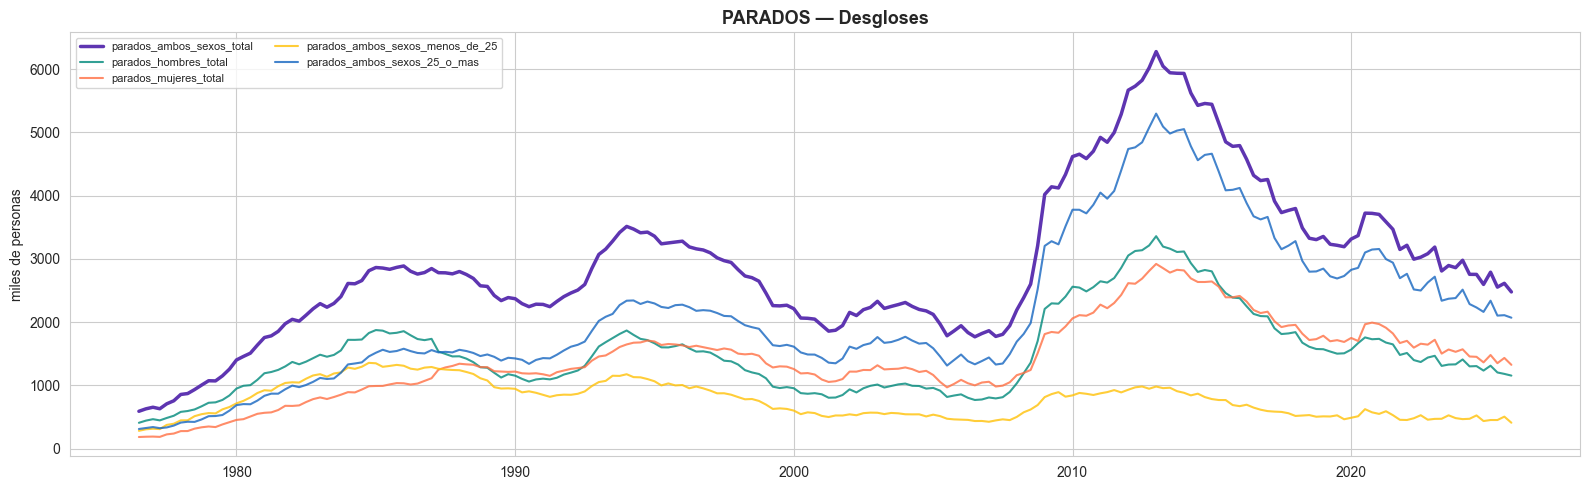

In [8]:
desgloses = [c for c in DATASET_CONFIG.get('variables_desgloses', []) if c in df.columns]

if desgloses:
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(y.index, y, color=COLOR_PRINCIPAL, lw=2.5, label=VAR_PRINCIPAL, zorder=5)

    for col, color in zip(desgloses, COLORES_DESGLOSES):
        serie = df[col].dropna()
        ax.plot(serie.index, serie, color=color, lw=1.5, alpha=0.8, label=col)

    ax.set_title(f'{NOMBRE.upper()} — Desgloses', fontsize=13, fontweight='bold')
    ax.set_ylabel(UNIDADES, fontsize=10)
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

### Análisis:

Hasta 1988 había siempre más hombres parados en términos absolutos, coherente con una fuerza laboral femenina aún pequeña. La incorporación masiva de la mujer al mercado laboral en los 80 explica la convergencia. El desempleo juvenil (<25) tiene ciclos de menor amplitud de ciclo y menor volumen en términos absoulutos. Aunque puede resultar llamativo devido a la alta temporalidad del empleo juvenil español, esto se debe a que los desempleados mayores de 25 son quienes domina tanto el nivel como la variación cíclic Y a la reducción de la demografía de los jóvenes de la población activa.
La compresión del desempleo juvenil absoluto post-2008 es llamativa. Aunque no refleja mejora en cuanto al desempleo, como decía antes, esto refleja que el grupo de jóvenes se redujo demográficamente y que muchos jóvenes abandonaron la búsqueda activa (efecto desánimo), saliendo de la categoría EPA de "parados". Además se puede ver también la reducción desde los inicios de la serie debido a la expansión de la educación universitaria que retrasa la entrada de los jóvenes al mercado laboral.

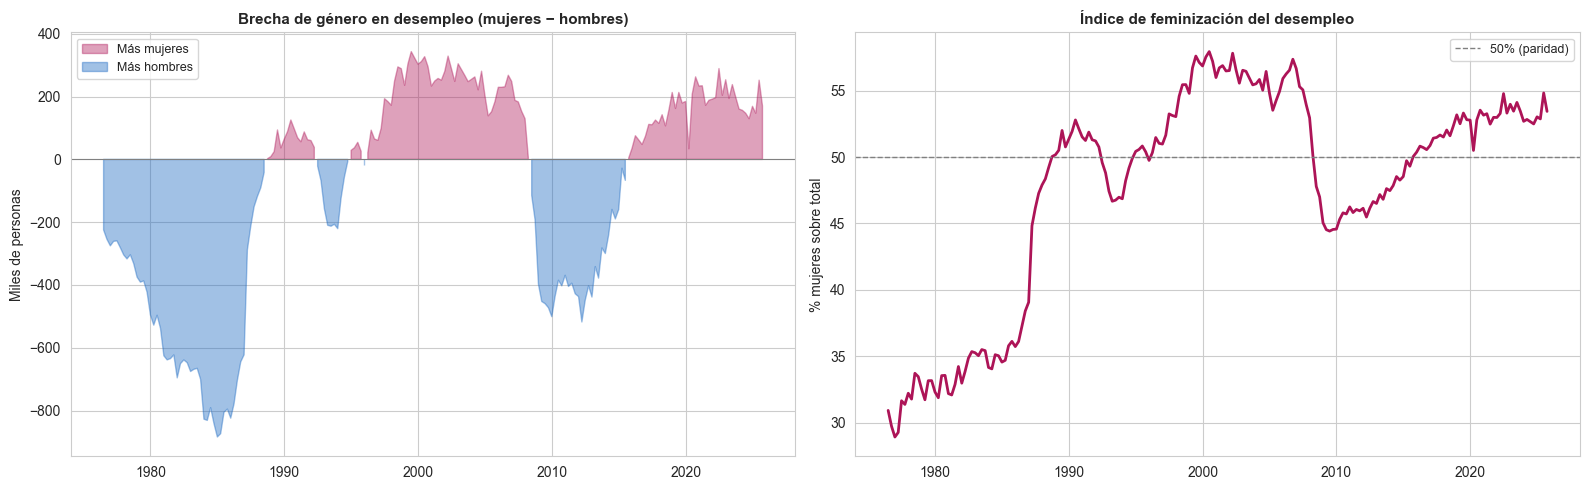

In [9]:
# Brecha de género y feminización del desempleo
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

brecha = df['parados_mujeres_total'] - df['parados_hombres_total']
axes[0].fill_between(brecha.index, brecha, 0, where=brecha >= 0, color='#AD1457', alpha=0.4, label='Más mujeres')
axes[0].fill_between(brecha.index, brecha, 0, where=brecha < 0, color='#1565C0', alpha=0.4, label='Más hombres')
axes[0].axhline(0, color='gray', lw=0.8)
axes[0].set_title('Brecha de género en desempleo (mujeres − hombres)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Miles de personas', fontsize=10)
axes[0].legend(fontsize=9)

fem = df['parados_mujeres_total'] / df['parados_ambos_sexos_total'] * 100
axes[1].plot(fem.index, fem, color='#AD1457', lw=2)
axes[1].axhline(50, color='gray', linestyle='--', lw=1, label='50% (paridad)')
axes[1].set_title('Índice de feminización del desempleo', fontsize=11, fontweight='bold')
axes[1].set_ylabel('% mujeres sobre total', fontsize=10)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### Análisis:
La transición de "más hombres parados" a "más mujeres paradas" refleja la incorporación de la mujer al mercado laboral, no un deterioro relativo. El índice de feminización cae bruscamente en 2008 porque la crisis destruyó empleo masivamente en construcción e industria (sectores masculinizados) haciendo que los hombres volvieran a ser mayoría en el paro durante 2008-2012. La recuperación posterior del índice por encima del 50% pasrece ser estructural.
El índice de feminización en 1976 (29%) implica que solo 3 de cada 10 parados eran mujeres. Esto vuelve a confirmar la ruptura de régimen desde el periodo inicial de la democracia hasta hoy.

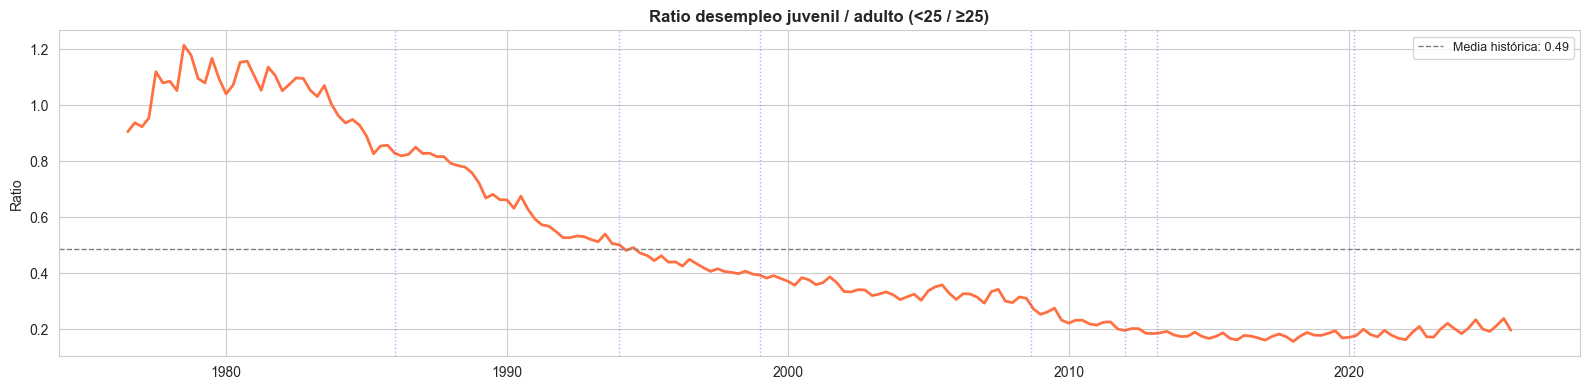

In [10]:
# Ratio desempleo juvenil vs adulto
ratio_juv = df['parados_ambos_sexos_menos_de_25'] / df['parados_ambos_sexos_25_o_mas']

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(ratio_juv.index, ratio_juv, color='#FF7043', lw=2)
ax.axhline(ratio_juv.mean(), color='gray', linestyle='--', lw=1,
           label=f'Media histórica: {ratio_juv.mean():.2f}')

for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if ratio_juv.index.min() <= fecha_ev <= ratio_juv.index.max():
        ax.axvline(fecha_ev, color='#7C4DFF', linestyle=':', lw=1, alpha=0.5)

ax.set_title('Ratio desempleo juvenil / adulto (<25 / ≥25)', fontsize=12, fontweight='bold')
ax.set_ylabel('Ratio', fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Análisis:
 Serie con tendencia decreciente estructural muy marcada. No estacionaria, y además potencialmente no recuperable por el cambio de régimen tan pronunciado. La media histórica de 0.49 carece de significado económico por la no estacionariedad de la ratio en sí misma.

En 1976, los jóvenes representaban en volumen absoluto casi el mismo número de parados que los adultos. Hoy son solo 20% del total. Esta caída estructural refleja simultáneamente: la reducción demográfica de la cohorte joven, expansión de la educación universitaria que retrasa la entrada al mercado, y efecto desánimo que saca a jóvenes de la población activa EPA. No es una mejora real del empleo juvenil, es un cambio estructural en la composición de la fuerza laboral.

---
### Tasa de paro

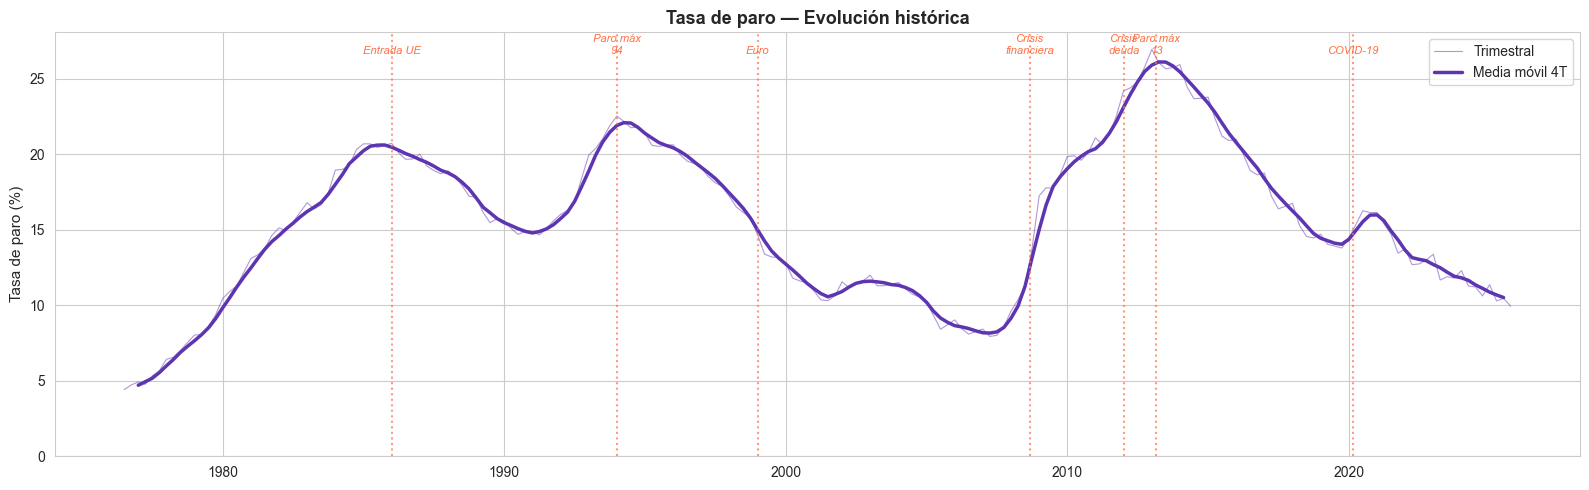

Rango: 1976-07-01 a 2025-10-01
Mínimo: 4.41% (1976-07-01)
Máximo: 26.94% (2013-01-01)
Media: 15.47%


In [11]:
# ── Serie temporal de la tasa de paro ──────────────────────────────────────
if 'tasa_paro_ambos_sexos_total' in df.columns:
    tasa = df['tasa_paro_ambos_sexos_total'].dropna()
    mm4_tasa = tasa.rolling(4, center=True).mean()

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(tasa.index, tasa, color='#5E35B1', lw=0.8, alpha=0.5, label='Trimestral')
    ax.plot(mm4_tasa.index, mm4_tasa, color='#5E35B1', lw=2.5, label='Media móvil 4T')

    for fecha_str, texto in EVENTOS.items():
        fecha_ev = pd.Timestamp(fecha_str)
        if tasa.index.min() <= fecha_ev <= tasa.index.max():
            ax.axvline(fecha_ev, color='#FF7043', linestyle=':', lw=1.5, alpha=0.7)
            ax.text(fecha_ev, ax.get_ylim()[1]*0.95, texto, ha='center', fontsize=8,
                    color='#FF7043', fontstyle='italic')

    ax.set_title('Tasa de paro — Evolución histórica', fontsize=13, fontweight='bold')
    ax.set_ylabel('Tasa de paro (%)', fontsize=11)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

    print(f'Rango: {tasa.index.min().date()} a {tasa.index.max().date()}')
    print(f'Mínimo: {tasa.min():.2f}% ({tasa.idxmin().date()})')
    print(f'Máximo: {tasa.max():.2f}% ({tasa.idxmax().date()})')
    print(f'Media: {tasa.mean():.2f}%')
else:
    print('AVISO: columna tasa_paro_ambos_sexos_total no encontrada.')
    print('Ejecutar primero el NB 1 de limpieza (Población) para añadir las tasas.')

### Análisis:
Serie no estacionaria con tres ciclos completos documentados. Rango 4.41%–26.94%, media histórica de 15.47% sin valor representativo dado que la serie no tiene media estable.
 Hay dos observaciones relevantes respecto a los absolutos.
 - Primera: el pico de 2013 (26.94%) que es el máximo histórico en tasa, también lo era en parados absolutos también lo era,
  - Segunda: el mínimo histórico es 4.41% en 1976-Q3, que es el primer dato disponible y corresponde a un momento en que la fuerza laboral española era estructuralmente distinta. La media de 15.47% está sesgada al alza por el peso del periodo 2008-2020 y no podemos interpretarla como nivel de equilibrio.

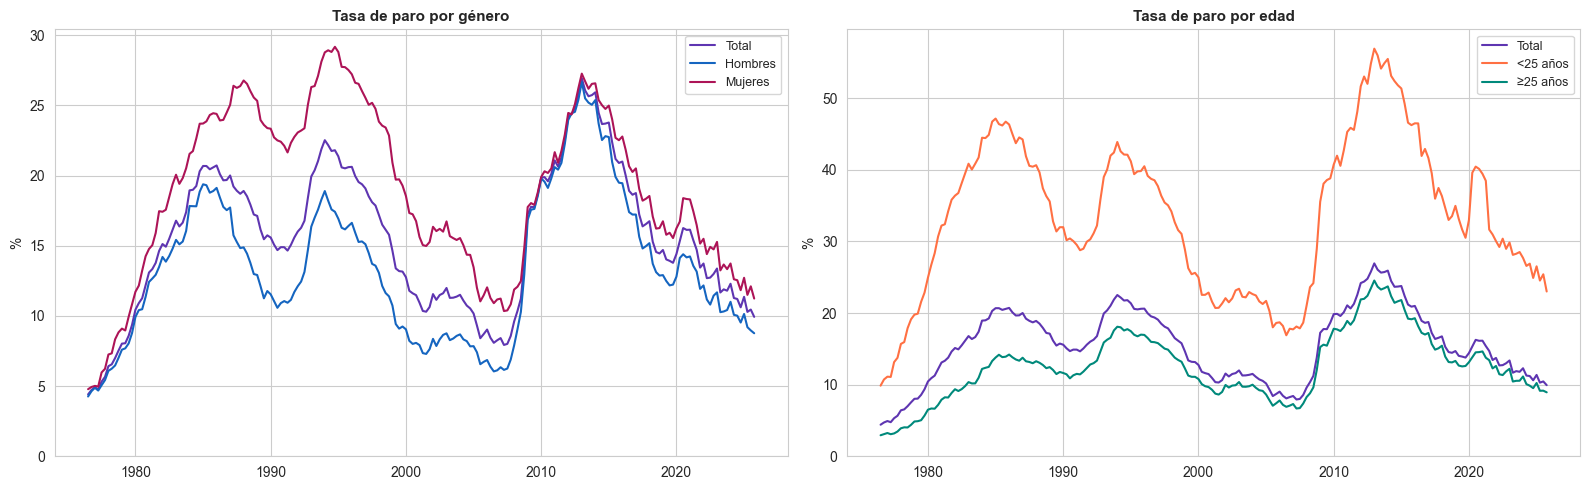

In [12]:
# ── Desgloses de la tasa por género y edad ────────────────────────────────
if 'tasa_paro_ambos_sexos_total' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Por género
    for col, label, color in [
        ('tasa_paro_ambos_sexos_total', 'Total', '#5E35B1'),
        ('tasa_paro_hombres_total', 'Hombres', '#1565C0'),
        ('tasa_paro_mujeres_total', 'Mujeres', '#AD1457'),
    ]:
        if col in df.columns:
            serie = df[col].dropna()
            axes[0].plot(serie.index, serie, color=color, lw=1.5, label=label)
    axes[0].set_title('Tasa de paro por género', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('%', fontsize=10)
    axes[0].legend(fontsize=9)
    axes[0].set_ylim(bottom=0)

    # Por edad
    for col, label, color in [
        ('tasa_paro_ambos_sexos_total', 'Total', '#5E35B1'),
        ('tasa_paro_ambos_sexos_menos_de_25', '<25 años', '#FF7043'),
        ('tasa_paro_ambos_sexos_25_o_mas', '≥25 años', '#00897B'),
    ]:
        if col in df.columns:
            serie = df[col].dropna()
            axes[1].plot(serie.index, serie, color=color, lw=1.5, label=label)
    axes[1].set_title('Tasa de paro por edad', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('%', fontsize=10)
    axes[1].legend(fontsize=9)
    axes[1].set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()

### Análisis:
 La tasa femenina es sistemáticamente superior a la masculina en todo el periodo salvo en el pico de 2011-2012. La tasa juvenil (<25) duplica o triplica la tasa adulta en todos los ciclos, con el mismo perfil temporal pero amplitud muy superior. Lo cual difiere con los resultados en valores absolutos.

A diferencia de los absolutos vistos antes, aquí sí se ve con claridad que el desempleo juvenil tiene ciclos de mayor amplitud relativa, llegando al 55% aproximadamente en 2013, frente al 26% de la tasa total. Esto confirma que la imagen de los absolutos era engañosa por el menor peso demográfico del colectivo, y que la tasa es una métrica más correcta para comparar intensidad entre grupos.

---
## 3. Distribución y Outliers

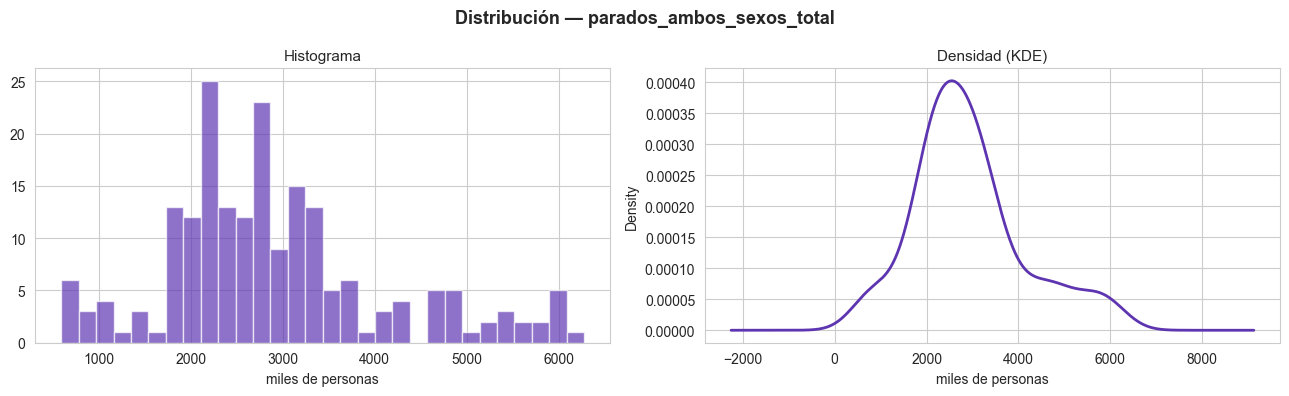

Asimetría (skewness): 0.761
Curtosis:             0.514


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Distribución — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].hist(y, bins=30, color=COLOR_PRINCIPAL, alpha=0.7, edgecolor='white')
axes[0].set_xlabel(UNIDADES, fontsize=10)
axes[0].set_title('Histograma', fontsize=11)

y.plot.kde(ax=axes[1], color=COLOR_PRINCIPAL, lw=2)
axes[1].set_xlabel(UNIDADES, fontsize=10)
axes[1].set_title('Densidad (KDE)', fontsize=11)

plt.tight_layout()
plt.show()

print(f'Asimetría (skewness): {y.skew():.3f}')
print(f'Curtosis:             {y.kurtosis():.3f}')

### Análisis:
 El modo principal se concentra en torno a 2.000-2.500 miles de personas, que corresponde al régimen "normal" de la serie en los periodos fuera de crisis severa. El segundo bulto visible en el KDE hacia 4.000-6.000 corresponde al periodo 2008-2013.


In [14]:
Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
IQR = Q3 - Q1
limite_inf_iqr = Q1 - 1.5 * IQR
limite_sup_iqr = Q3 + 1.5 * IQR

z_scores = np.abs(stats.zscore(y.dropna()))
outliers_z = y[z_scores > 3]
outliers_iqr = y[(y < limite_inf_iqr) | (y > limite_sup_iqr)]

print(f'Outliers por IQR  (1.5×): {len(outliers_iqr)}')
print(f'Outliers por z-score (>3): {len(outliers_z)}')

extremos = pd.concat([
    y.nsmallest(5).rename('valor'),
    y.nlargest(5).rename('valor')
]).sort_values()

print('\n10 valores extremos (5 mínimos + 5 máximos):')
print(extremos.to_frame().reset_index().to_string(index=False))

Outliers por IQR  (1.5×): 15
Outliers por z-score (>3): 0

10 valores extremos (5 mínimos + 5 máximos):
     fecha    valor
1976-07-01  589.000
1976-10-01  627.772
1977-04-01  629.137
1977-01-01  652.868
1977-07-01  707.185
2013-10-01 5935.600
2013-07-01 5943.400
2012-10-01 6021.000
2013-04-01 6047.300
2013-01-01 6278.200


### Análisis:
La discrepancia entre ambos métodos es informativa. El IQR detecta 15 valores porque es sensible a la asimetría de la distribución, especialmente cuando la caja está desplazada hacia los valores bajos. El z-score no detecta ninguno porque los valores extremos, aunque alejados de la media, no superan 3 desviaciones típicas dada la alta varianza de la serie completa. Ambos resultados son correctos y consistentes entre sí, simplemente miden cosas distintas.

In [15]:
if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
    y_periodo = y.index.quarter.map({1:'T1', 2:'T2', 3:'T3', 4:'T4'})
    titulo_grupo = 'Trimestre'
    orden_periodos = ['T1', 'T2', 'T3', 'T4']
elif DATASET_CONFIG['frecuencia_original'] == 'mensual':
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses
else:
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses

colores_bp = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
               '#1565C0', '#AD1457', '#2E7D32', '#E65100',
               '#6A1B9A', '#00695C', '#F57F17', '#37474F']

df_box = pd.DataFrame({
    'periodo': y_periodo.values,
    'valor': y.values,
    'fecha': y.index.strftime('%Y-%m-%d'),
})
df_box['periodo'] = pd.Categorical(df_box['periodo'],
                                    categories=[p for p in orden_periodos if p in df_box['periodo'].values],
                                    ordered=True)

fig = px.box(
    df_box, x='periodo', y='valor', color='periodo',
    hover_data=['fecha'],
    title=f'Distribución por {titulo_grupo} — {VAR_PRINCIPAL}',
    labels={'valor': UNIDADES, 'periodo': titulo_grupo, 'fecha': 'Fecha'},
    color_discrete_sequence=colores_bp,
    category_orders={'periodo': orden_periodos},
)
fig.update_layout(showlegend=False, height=420)
fig.show()

### Análisis:
 La separación entre trimestres es visualmente pequeña en términos de mediana y rango intercuartílico, lo que sugiere que la estacionalidad en valores absolutos es moderada. Los outliers corresponden al periodo de 2012-2015 tras la crisis de deuda, aparecen en todos los trimestres sin excepción.

T1 muestra una mediana ligeramente superior y una caja algo más alta que el resto, consistente con el patrón estacional conocido del mercado laboral español (fin de campaña navideña y turística). Sin embargo, la diferencia entre trimestres es pequeña en términos absolutos.

---
### Tasa de paro

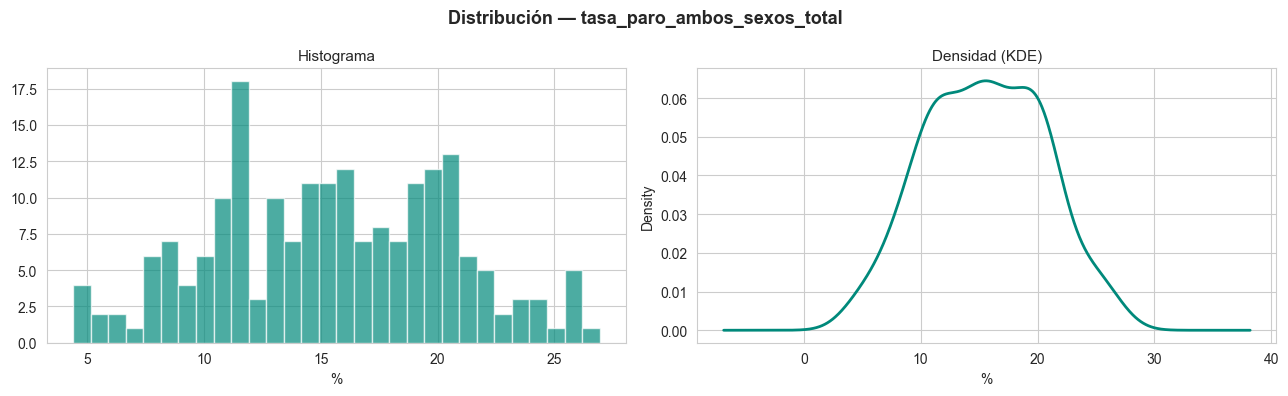

Asimetría (skewness): 0.001
Curtosis:             -0.654


In [16]:
# Distribución: tasa de paro
if 'tasa_paro_ambos_sexos_total' in df.columns:
    tasa = df['tasa_paro_ambos_sexos_total'].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle('Distribución — tasa_paro_ambos_sexos_total', fontsize=13, fontweight='bold')

    axes[0].hist(tasa, bins=30, color='#00897B', alpha=0.7, edgecolor='white')
    axes[0].set_xlabel('%', fontsize=10)
    axes[0].set_title('Histograma', fontsize=11)

    tasa.plot.kde(ax=axes[1], color='#00897B', lw=2)
    axes[1].set_xlabel('%', fontsize=10)
    axes[1].set_title('Densidad (KDE)', fontsize=11)
    plt.tight_layout()
    plt.show()

    print(f'Asimetría (skewness): {tasa.skew():.3f}')
    print(f'Curtosis:             {tasa.kurtosis():.3f}')



### Análisis:
Distribución prácticamente simétrica (skewness 0.001), platicúrtica (curtosis -0.654), sin outliers por ningún método. Forma aproximadamente uniforme entre 10% y 21%.

La curtosis negativa significa que la distribución tiene colas más ligeras y una cima más plana que una normal. Dicho de forma directa: la tasa de paro no se ha concentrado en ningún valor central concreto a lo largo de la historia, sino que ha pasado tiempo repartido de forma relativamente uniforme entre el 10% y el 21%.

La ausencia total de outliers por ambos métodos indica que los valores extremos (4.41% y 26.94%) son alcanzables dentro de la varianza histórica  de la serie. Como la serie ha pasado periodos prolongados en niveles altos (2008-2020), la varianza histórica total es tan grande que incluso el 26.94% queda dentro de los umbrales de ambos métodos.

El skewness de 0.001 es llamativamente cercano a cero para una serie macroeconómica con ciclos tan asimétricosEsto es porque no refleja simetría estructural, sino que los periodos de paro alto y paro bajo se compensan en longitud a lo largo de la muestra completa, lo que es un artefacto del periodo de observación elegido, no una propiedad intrínseca de la serie.

In [17]:
    Q1_t, Q3_t = tasa.quantile(0.25), tasa.quantile(0.75)
    IQR_t = Q3_t - Q1_t
    outliers_iqr_tasa = tasa[(tasa < Q1_t - 1.5*IQR_t) | (tasa > Q3_t + 1.5*IQR_t)]
    outliers_z_tasa = tasa[np.abs(stats.zscore(tasa)) > 3]
    print(f'Outliers por IQR  (1.5×): {len(outliers_iqr_tasa)}')
    print(f'Outliers por z-score (>3): {len(outliers_z_tasa)}')

    tasa_periodo = tasa.index.quarter.map({1:'T1', 2:'T2', 3:'T3', 4:'T4'})
    df_box_t = pd.DataFrame({
        'periodo': tasa_periodo.values,
        'valor': tasa.values,
        'fecha': tasa.index.strftime('%Y-%m-%d'),
    })
    df_box_t['periodo'] = pd.Categorical(
        df_box_t['periodo'], categories=['T1','T2','T3','T4'], ordered=True
    )
    fig2 = px.box(
        df_box_t, x='periodo', y='valor', color='periodo',
        hover_data=['fecha'],
        title='Distribución por Trimestre — tasa_paro_ambos_sexos_total',
        labels={'valor': '%', 'periodo': 'Trimestre', 'fecha': 'Fecha'},
        color_discrete_sequence=['#7C4DFF','#00897B','#FF7043','#FFC107'],
        category_orders={'periodo': ['T1','T2','T3','T4']},
    )
    fig2.update_layout(showlegend=False, height=420)
    fig2.show()

Outliers por IQR  (1.5×): 0
Outliers por z-score (>3): 0


### Análisis:
T1 tiene la mediana y la caja más altas, T3 las más bajas. La diferencia es visible pero no pronunciada, consistente con los índices estacionales débiles vistos en la descomposición de parados absolutos.
El patrón trimestral es el esperado, T1 más alto y T3 más bajo. Sin embargo, la separación entre cajas es pequeña en relación a la varianza total de cada trimestre, lo que indica que la variabilidad cíclica de largo plazo domina sobre la estacionalidad.

---
## 4. Estacionalidad

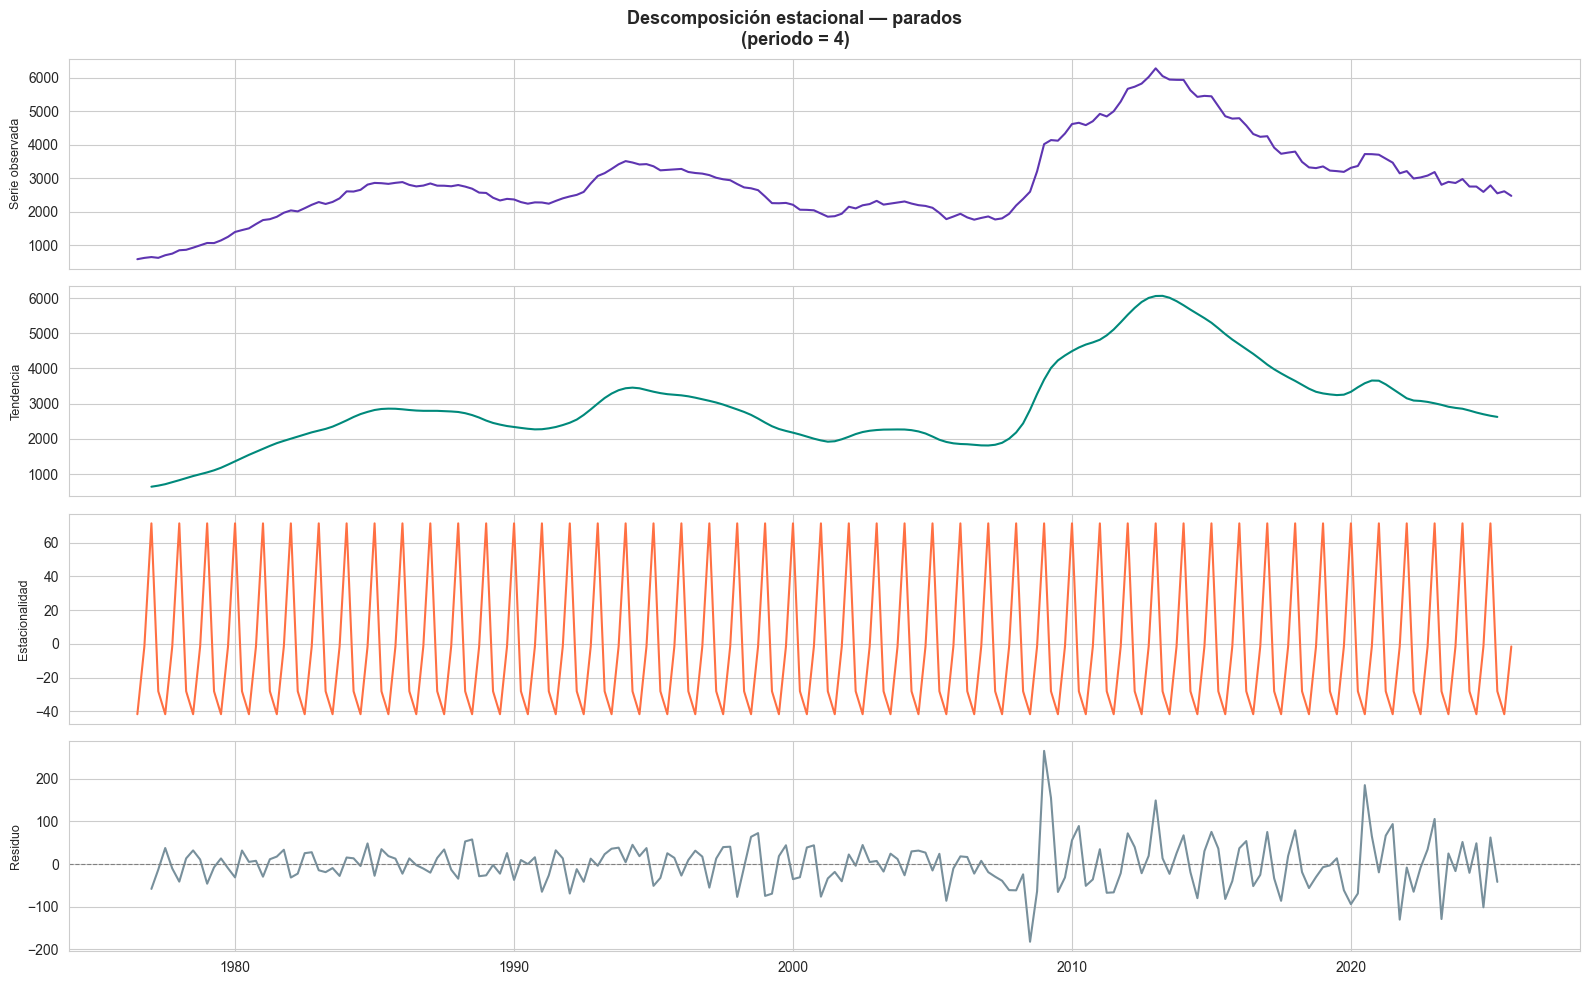

In [18]:
y_descomp = y.dropna()

if len(y_descomp) >= 2 * PERIODO_ESTACIONAL:
    descomp = seasonal_decompose(y_descomp, model='additive', period=PERIODO_ESTACIONAL)

    fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
    fig.suptitle(f'Descomposición estacional — {NOMBRE}\n(periodo = {PERIODO_ESTACIONAL})',
                 fontsize=13, fontweight='bold')

    componentes = [
        ('Serie observada', descomp.observed, COLOR_PRINCIPAL),
        ('Tendencia', descomp.trend, '#00897B'),
        ('Estacionalidad', descomp.seasonal, '#FF7043'),
        ('Residuo', descomp.resid, '#78909C'),
    ]

    for ax, (titulo, datos, color) in zip(axes, componentes):
        ax.plot(datos.index, datos, color=color, lw=1.5)
        ax.set_ylabel(titulo, fontsize=9)
        if titulo == 'Residuo':
            ax.axhline(0, color='gray', linestyle='--', lw=0.8)

    plt.tight_layout()
    plt.show()
else:
    print(f'Serie demasiado corta para descomposición (necesita ≥ {2*PERIODO_ESTACIONAL} obs, tiene {len(y_descomp)})')

### Análisis:
El componente de estacionalidad oscila entre aproximadamente -40 y +70 miles de personas, sobre una serie que en nivel llega a 6.000. Eso representa menos del 2% del nivel en los periodos de crisis. El residuo, en cambio, llega a ±200-300 miles en torno a 2008-2009 y 2020, lo que indica que los choques de crisis no son capturados ni por la tendencia ni por la estacionalidad, y quedan en el residuo como eventos atípicos. Esto indica la necesidad de dummies de crisis como regresores.
 La amplitud del componente estacional parece constante a lo largo de toda la muestra, lo que es consistente con un modelo aditivo. Si la amplitud creciera proporcionalmente al nivel de la serie, lo correcto sería un modelo multiplicativo. Aquí no se observa ese crecimiento proporcional, así que el modelo aditivo es apropiado para esta serie en nivel.

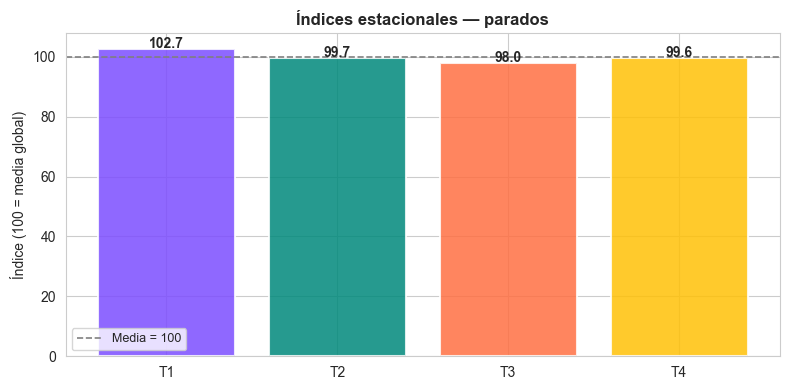

Índices estacionales:
T1   102.700
T2    99.700
T3    98.000
T4    99.600

Periodo con mayor parados: T1 (102.7)
Periodo con menor parados: T3 (98.0)


In [19]:
if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):

    if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
        grupo_idx = y.index.quarter
        etiq_idx = ['T1', 'T2', 'T3', 'T4']
    else:
        grupo_idx = y.index.month
        etiq_idx = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

    media_por_periodo = pd.Series(
        {p: y[grupo_idx == p].mean() for p in sorted(np.unique(grupo_idx))}
    )
    indice_estacional = (media_por_periodo / media_por_periodo.mean() * 100).round(1)
    indice_estacional.index = etiq_idx[:len(indice_estacional)]

    fig, ax = plt.subplots(figsize=(8, 4))
    colores_idx = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
                   '#1565C0', '#AD1457', '#2E7D32', '#E65100',
                   '#6A1B9A', '#00695C', '#F57F17', '#37474F']
    barras = ax.bar(indice_estacional.index, indice_estacional.values,
                    color=colores_idx[:len(indice_estacional)], edgecolor='white',
                    linewidth=1.5, alpha=0.85)
    ax.axhline(100, color='gray', linestyle='--', lw=1.2, label='Media = 100')
    ax.set_title(f'Índices estacionales — {NOMBRE}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Índice (100 = media global)', fontsize=10)
    for b, v in zip(barras, indice_estacional.values):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print('Índices estacionales:')
    print(indice_estacional.to_string())
    print(f'\nPeriodo con mayor {NOMBRE}: {indice_estacional.idxmax()} ({indice_estacional.max():.1f})')
    print(f'Periodo con menor {NOMBRE}: {indice_estacional.idxmin()} ({indice_estacional.min():.1f})')

### Análisis:
T1 está un 2.7% por encima de la media anual y T3 un 2% por debajo. Es el patrón esperado en el mercado laboral español (más paro en Q1 tras el fin de campaña navideña y turística, menos en Q3 en plena temporada), pero la magnitud es pequeña sobre parados absolutos. Açun así, estos índices son sorprendentemente planos para España, que tiene una de las estacionalidades laborales más pronunciadas de Europa. La estacionalidad en parados absolutos es estadísticamente presente pero económicamente muy débil. La diferencia entre el trimestre más alto (T1, 102.7) y el más bajo (T3, 98.0) es de apenas 4.7 puntos sobre base 100.

---
### Tasa de paro

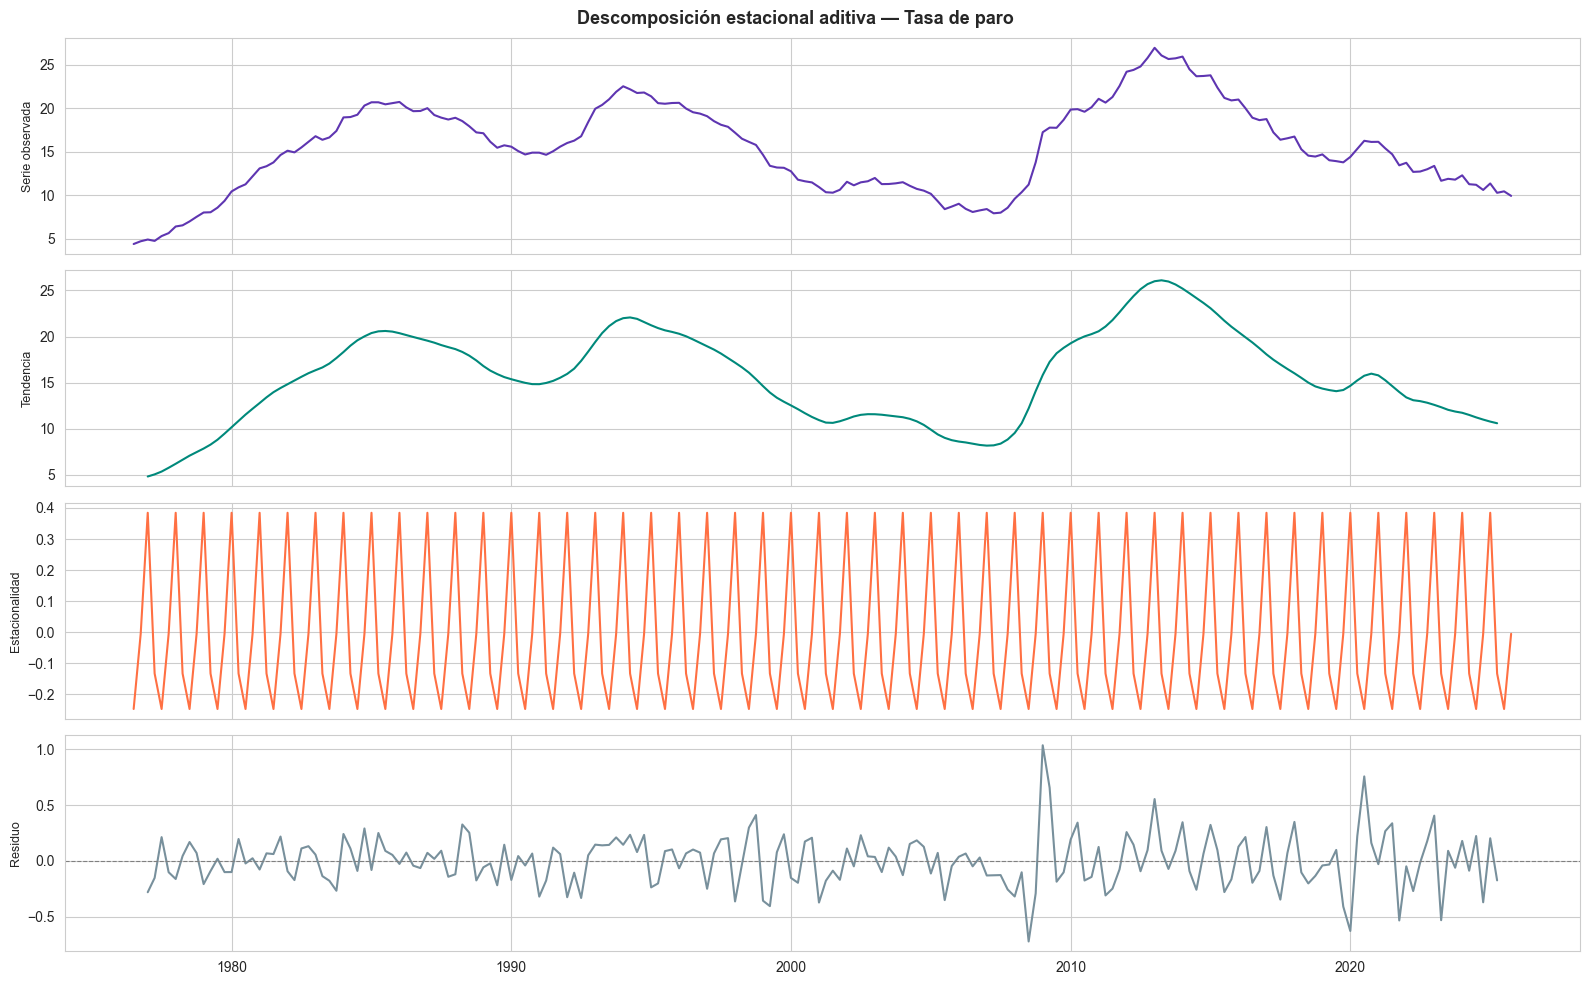

Índices estacionales de la TASA DE PARO (pp respecto a la media):
  T1: +0.384 pp
  T2: -0.133 pp
  T3: -0.247 pp
  T4: -0.005 pp


In [20]:
# ── Descomposición estacional de la tasa de paro ──────────────────────────
if 'tasa_paro_ambos_sexos_total' in df.columns:
    tasa = df['tasa_paro_ambos_sexos_total'].dropna()

    descomp_tasa = seasonal_decompose(tasa, model='additive', period=PERIODO_ESTACIONAL)

    fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
    fig.suptitle('Descomposición estacional aditiva — Tasa de paro',
                 fontsize=13, fontweight='bold')

    for ax, (titulo, datos, color) in zip(axes, [
        ('Serie observada', descomp_tasa.observed, COLOR_PRINCIPAL),
        ('Tendencia', descomp_tasa.trend, '#00897B'),
        ('Estacionalidad', descomp_tasa.seasonal, '#FF7043'),
        ('Residuo', descomp_tasa.resid, '#78909C'),
    ]):
        ax.plot(datos.index, datos, color=color, lw=1.5)
        ax.set_ylabel(titulo, fontsize=9)
        if titulo == 'Residuo':
            ax.axhline(0, color='gray', linestyle='--', lw=0.8)

    plt.tight_layout()
    plt.show()

    # Índices estacionales de la tasa
    est_tasa = descomp_tasa.seasonal.groupby(descomp_tasa.seasonal.index.quarter).mean()
    print('Índices estacionales de la TASA DE PARO (pp respecto a la media):')
    for q, v in est_tasa.items():
        print(f'  T{q}: {v:+.3f} pp')

### Análisis:
Estacionalidad presente, regular y de amplitud constante a lo largo de toda la muestra. Indica que el modelo aditivo es apropiado. Residuos con anomalías claras en 2008-2009 y 2020 que requerirán tratamiento explícito.

El componente de tendencia replica los tres ciclos ya identificados en la serie. El componente estacional oscila entre aproximadamente -0.25 y +0.35 puntos porcentuales con un patrón que se repite cada 4 trimestres de forma estable durante toda la muestra. La amplitud no crece con el nivel de la serie, lo que valida el modelo aditivo frente al multiplicativo.

El residuo permanece pequeño y centrado en cero durante la mayor parte del periodo, con dos excepciones visibles. Justo antes de 2008 aparece un residuo negativo, que es un artefacto mecánico de la media móvil: al estimar la tendencia usa observaciones futuras, incorpora anticipadamente los valores altos del pico de crisis, y sobreestima la tendencia en los trimestres previos, haciendo que la tasa observada quede por debajo de lo que la tendencia predice. A continuación, en 2008-2009, el residuo sube bruscamente: la tasa observada superó lo que tendencia más estacionalidad predecían porque el choque fue más rápido e intenso de lo que la tendencia podía capturar. En 2020 ocurre un pico similar por el mismo motivo.

Su tratamiento se decidirá en la fase de modelización.

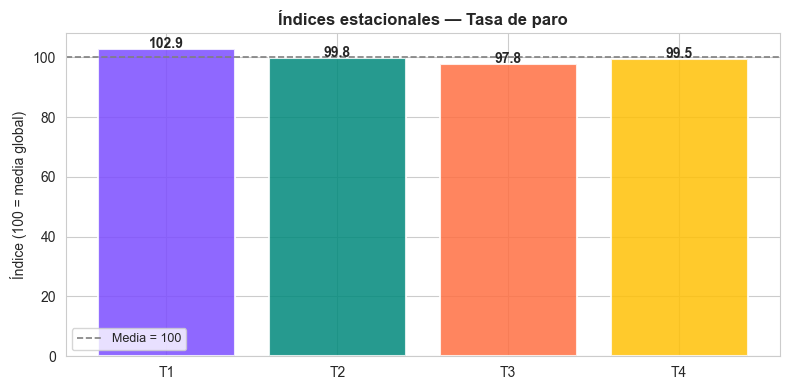

Índices estacionales (tasa de paro):
T1   102.900
T2    99.800
T3    97.800
T4    99.500

Periodo con mayor tasa de paro: T1 (102.9)
Periodo con menor tasa de paro: T3 (97.8)


In [21]:
if 'tasa_paro_ambos_sexos_total' in df.columns:
    tasa = df['tasa_paro_ambos_sexos_total'].dropna()

    if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
        grupo_idx_t = tasa.index.quarter
        etiq_idx_t = ['T1', 'T2', 'T3', 'T4']
    else:
        grupo_idx_t = tasa.index.month
        etiq_idx_t = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

    media_por_periodo_t = pd.Series(
        {p: tasa[grupo_idx_t == p].mean() for p in sorted(np.unique(grupo_idx_t))}
    )
    indice_estacional_t = (media_por_periodo_t / media_por_periodo_t.mean() * 100).round(1)
    indice_estacional_t.index = etiq_idx_t[:len(indice_estacional_t)]

    fig, ax = plt.subplots(figsize=(8, 4))
    colores_idx = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
                   '#1565C0', '#AD1457', '#2E7D32', '#E65100',
                   '#6A1B9A', '#00695C', '#F57F17', '#37474F']
    barras = ax.bar(indice_estacional_t.index, indice_estacional_t.values,
                    color=colores_idx[:len(indice_estacional_t)], edgecolor='white',
                    linewidth=1.5, alpha=0.85)
    ax.axhline(100, color='gray', linestyle='--', lw=1.2, label='Media = 100')
    ax.set_title('Índices estacionales — Tasa de paro', fontsize=12, fontweight='bold')
    ax.set_ylabel('Índice (100 = media global)', fontsize=10)
    for b, v in zip(barras, indice_estacional_t.values):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print('Índices estacionales (tasa de paro):')
    print(indice_estacional_t.to_string())
    print(f'\nPeriodo con mayor tasa de paro: {indice_estacional_t.idxmax()} ({indice_estacional_t.max():.1f})')
    print(f'Periodo con menor tasa de paro: {indice_estacional_t.idxmin()} ({indice_estacional_t.min():.1f})')

### Análisis:
T1 es el trimestre con mayor tasa de paro (índice 102.9, es decir, un 2.9% por encima de la media anual) y T3 el de menor (97.8, un 2.2% por debajo). En puntos porcentuales absolutos: T1 +0.384 pp, T3 -0.247 pp respecto a la media. La estacionalidad de la tasa de paro es estadísticamente presente y regular, pero económicamente débil. Una diferencia de 0.63 pp entre el trimestre más alto y el más bajo, sobre una serie que oscila entre 4% y 27%, es una señal estacional de baja magnitud.

Los índices de la tasa (T1=102.9, T3=97.8) son prácticamente idénticos a los de los parados absolutos vistos antes (T1=102.7, T3=98.0). Esto indica que la estacionalidad del denominador (activos) es suficientemente pequeña como para no distorsionar la ratio

---
## 5. Cambios Periodo a Periodo

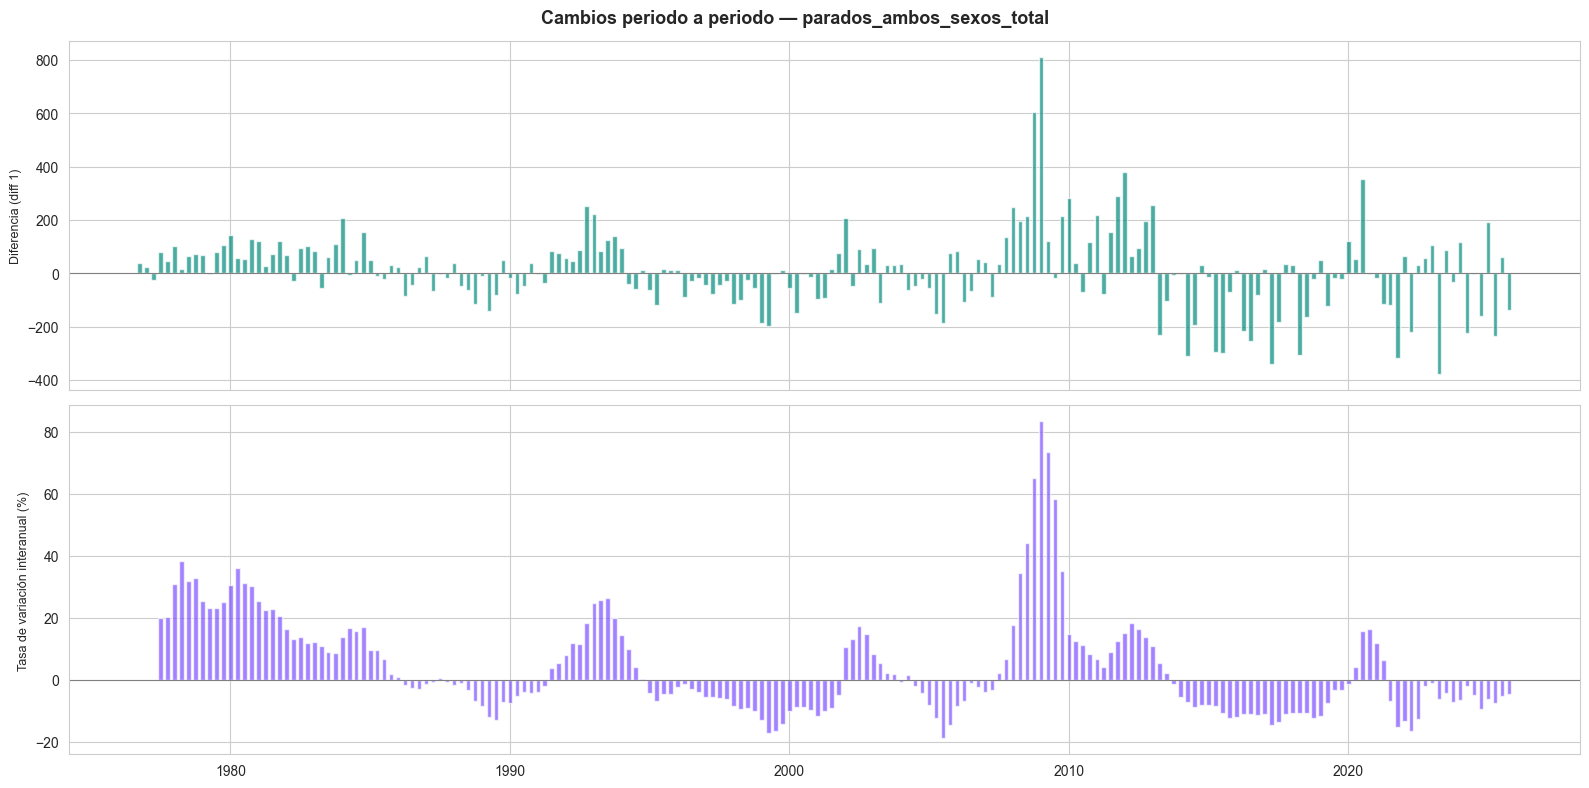

Estadísticas de la variación interanual (%):
count   194.000
mean      4.140
std      16.510
min     -18.920
25%      -7.410
50%      -1.420
75%      12.880
max      83.440


In [22]:
diff1 = y.diff(1).dropna()
diff_est = y.diff(PERIODO_ESTACIONAL).dropna()  # se usa en Sección 6 (stationarity test)
pct_yoy = y.pct_change(PERIODO_ESTACIONAL).dropna() * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle(f'Cambios periodo a periodo — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].bar(diff1.index, diff1, color='#00897B', alpha=0.7, width=60)
axes[0].axhline(0, color='gray', lw=0.8)
axes[0].set_ylabel('Diferencia (diff 1)', fontsize=9)

axes[1].bar(pct_yoy.index, pct_yoy, color='#7C4DFF', alpha=0.7, width=60)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].set_ylabel('Tasa de variación interanual (%)', fontsize=9)

plt.tight_layout()
plt.show()

print('Estadísticas de la variación interanual (%):')
print(pct_yoy.describe().round(2).to_string())

### Análisis:
El panel superior (diferencia de orden 1) muestra un patrón de alternancia positivo-negativo regular fuera de los periodos de crisis, señal de que la estacionalidad persiste tras esta transformación. No es la transformación adecuada para estas series. El panel inferior (pct_change(4)) elimina ese patrón y produce una serie que oscila alrededor de cero en los periodos de estabilidad, con episodios de expansión claramente delimitados en 1977-1984, 1991-1994, 2008-2012 y 2020. La desviación típica de 16.51% está dominada por esos episodios. La mediana de -1.42% es más representativa que la media de 4.14%, que está sesgada al alza por los picos de crisis.

---
### Tasa de paro

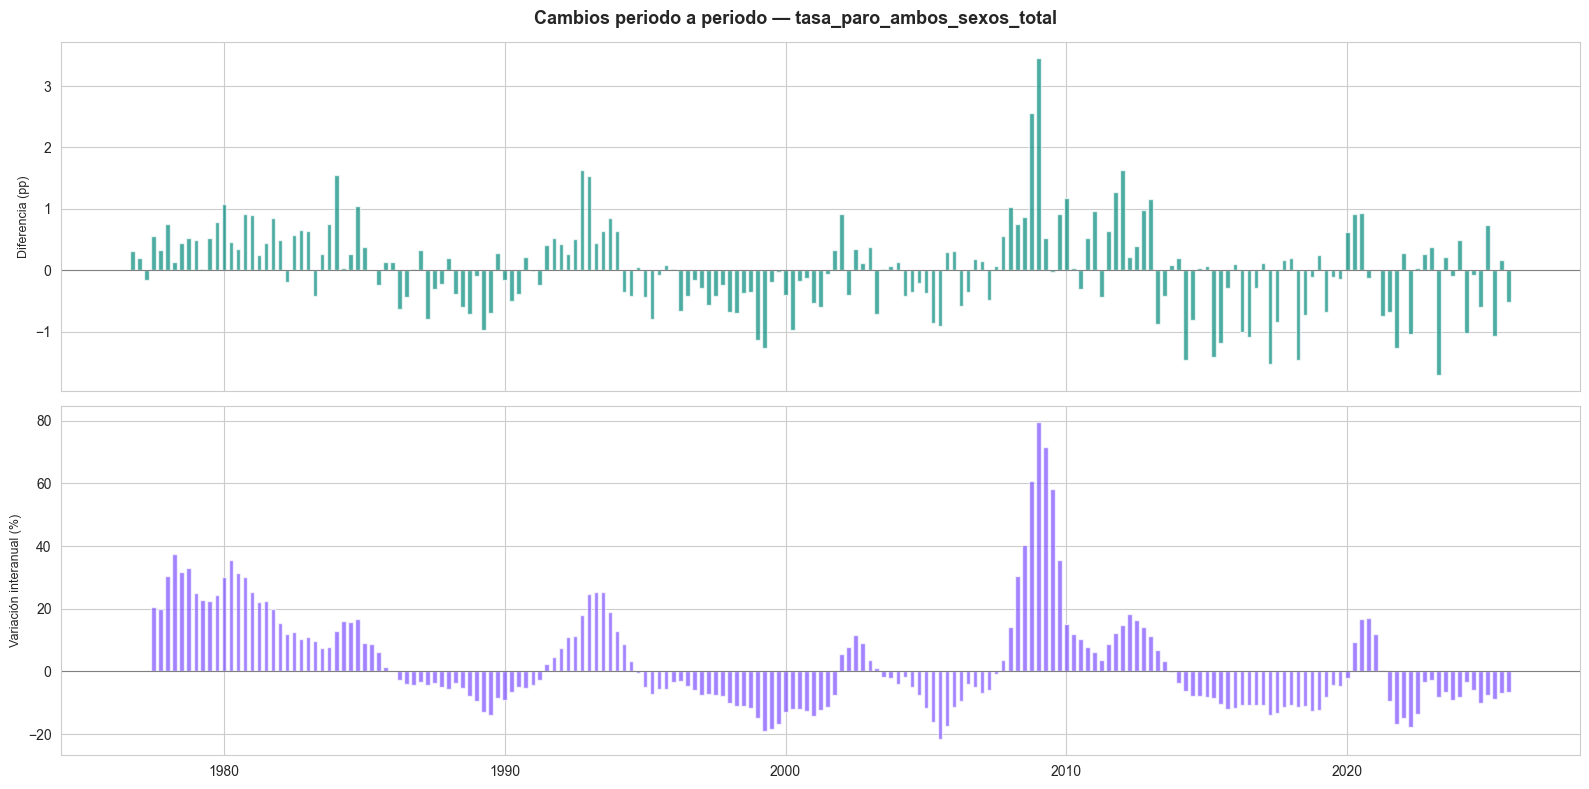

Estadísticas variación interanual (%) — tasa:
count   194.000
mean      2.840
std      16.570
min     -21.660
25%      -8.610
50%      -3.470
75%      11.820
max      79.560


In [23]:
# Cambios periodo a periodo: tasa de paro
if 'tasa_paro_ambos_sexos_total' in df.columns:
    tasa = df['tasa_paro_ambos_sexos_total'].dropna()
    tasa_diff1 = tasa.diff(1).dropna()
    tasa_pct_yoy = tasa.pct_change(PERIODO_ESTACIONAL).dropna() * 100

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    fig.suptitle('Cambios periodo a periodo — tasa_paro_ambos_sexos_total',
                 fontsize=13, fontweight='bold')

    axes[0].bar(tasa_diff1.index, tasa_diff1, color='#00897B', alpha=0.7, width=60)
    axes[0].axhline(0, color='gray', lw=0.8)
    axes[0].set_ylabel('Diferencia (pp)', fontsize=9)

    axes[1].bar(tasa_pct_yoy.index, tasa_pct_yoy, color='#7C4DFF', alpha=0.7, width=60)
    axes[1].axhline(0, color='gray', lw=0.8)
    axes[1].set_ylabel('Variación interanual (%)', fontsize=9)

    plt.tight_layout()
    plt.show()

    print('Estadísticas variación interanual (%) — tasa:')
    print(tasa_pct_yoy.describe().round(2).to_string())

### Análisis:
El panel superior muestra la diferencia trimestral en puntos porcentuales (Δ₁). La serie oscila en torno a cero con variaciones típicas de ±0,5 pp, pero presenta picos de gran magnitud asociados a episodios recesivos, especialmente en 2008-2009 con incrementos superiores a 2,5 pp por trimestre. Este comportamiento refleja heterocedasticidad con clusters de volatilidad en periodos de crisis.
El panel inferior recoge la variación interanual (pct_change(4)), que elimina el componente estacional comparando cada trimestre con el mismo periodo del año anterior. Las estadísticas descriptivas muestran una media de 2,84% con desviación típica de 16,57%, y una mediana de −3,47%, lo que confirma que la tasa ha descendido en más trimestres de los que ha aumentado. Sin embargo, los episodios alcistas son de mayor magnitud, con un máximo de +79,56% en 2008-2009 frente a un mínimo de −21,66%. Esta asimetría es característica de los ciclos de desempleo en España: las fases de deterioro son bruscas y concentradas, mientras que las de mejora son graduales y prolongadas.

---
## 6. Estacionariedad y Autocorrelación

In [24]:
def test_estacionariedad(serie, nombre_serie, regression='c'):
    s = serie.dropna()
    adf_stat, adf_p, _, _, _, _ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, _, _ = kpss(s, regression=regression, nlags='auto')
    estacionaria = (adf_p < 0.05) and (kpss_p >= 0.05)
    return {
        'serie': nombre_serie,
        'regression': regression,
        'ADF_stat': round(adf_stat, 4),
        'ADF_p': round(adf_p, 4),
        'ADF_H0_rechaza': adf_p < 0.05,
        'KPSS_stat': round(kpss_stat, 4),
        'KPSS_p': round(kpss_p, 4),
        'KPSS_H0_rechaza': kpss_p < 0.05,
        'conclusion': 'ESTACIONARIA' if estacionaria else 'NO ESTACIONARIA',
    }

series_test = [
    (y, f'{VAR_PRINCIPAL} (nivel)', 'c'),
    (diff1, f'{VAR_PRINCIPAL} (diff 1)', 'c'),
    (diff_est, f'{VAR_PRINCIPAL} (diff {PERIODO_ESTACIONAL})', 'c'),
]

resultados_est = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test])

print('Tests de estacionariedad — PARADOS')
print('=' * 85)
print(resultados_est.to_string(index=False))
print()
print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
for _, row in resultados_est.iterrows():
    print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
    h0_adf = 'rechaza H₀' if row['ADF_H0_rechaza'] else 'NO rechaza H₀'
    h0_kpss = 'rechaza H₀' if row['KPSS_H0_rechaza'] else 'NO rechaza H₀'
    print(f"    ADF  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
    print(f"    KPSS stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
    print(f"    → {row['conclusion']}")
    print()


Tests de estacionariedad — PARADOS
                             serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza      conclusion
 parados_ambos_sexos_total (nivel)          c    -2.605  0.092           False      0.842   0.010             True NO ESTACIONARIA
parados_ambos_sexos_total (diff 1)          c    -2.840  0.053           False      0.222   0.100            False NO ESTACIONARIA
parados_ambos_sexos_total (diff 4)          c    -3.169  0.022            True      0.191   0.100            False    ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  parados_ambos_sexos_total (nivel)  (KPSS regression='c')
    ADF  stat=-2.605, p=0.0920 (NO rechaza H₀)
    KPSS stat=0.842, p=0.0100 (rechaza H₀)
    → NO ESTACIONARIA

  parados_ambos_sexos_total (diff 1)  (KPSS regression='c')
    ADF  stat=-2.840, p=0.0528 (NO rechaza H₀)
    KPSS stat=0.222, p=0.1000 (NO rechaza H₀)
    → NO ESTACIONARIA

  parados_ambos_sexos_total

### Análisis:
Se aplican conjuntamente el test Augmented Dickey-Fuller (ADF) y el test KPSS (Kwiatkowski-Phillips-Schmidt-Shin), cuyas hipótesis nulas son opuestas: el ADF asume que la serie tiene raíz unitaria (no estacionaria), mientras que el KPSS asume que la serie es estacionaria. Esta dualidad permite un diagnóstico más robusto que cualquiera de los dos tests por separado.
- Serie original: el ADF no rechaza su H₀ (p = 0,092 > 0,05) y el KPSS sí rechaza la suya (p = 0,010 < 0,05). Ambos tests apuntan en la misma dirección: la serie en niveles no es estacionaria.
- Diferencia respecto al trimestre anterior: el ADF sigue sin rechazar su H₀ (p = 0,053), rozando el umbral pero sin superarlo, mientras que el KPSS ya no rechaza la suya (p = 0,100). Los tests ofrecen señales contradictorias, por lo que se aplica el criterio conservador y se concluye que la serie no es estacionaria. Este resultado es consistente con los correlogramas ACF/PACF, donde persisten picos significativos en el lag 4 que evidencian estructura estacional residual no eliminada por la diferenciación simple.
- Diferencia interanual: el ADF rechaza su H₀ (p = 0,022 < 0,05) y el KPSS no rechaza la suya (p = 0,100). Ambos tests convergen: la serie diferenciada en orden 4 es estacionaria. La diferenciación interanual elimina tanto la tendencia estocástica como el componente estacional trimestral, lo que es coherente con la naturaleza de los datos de la EPA.

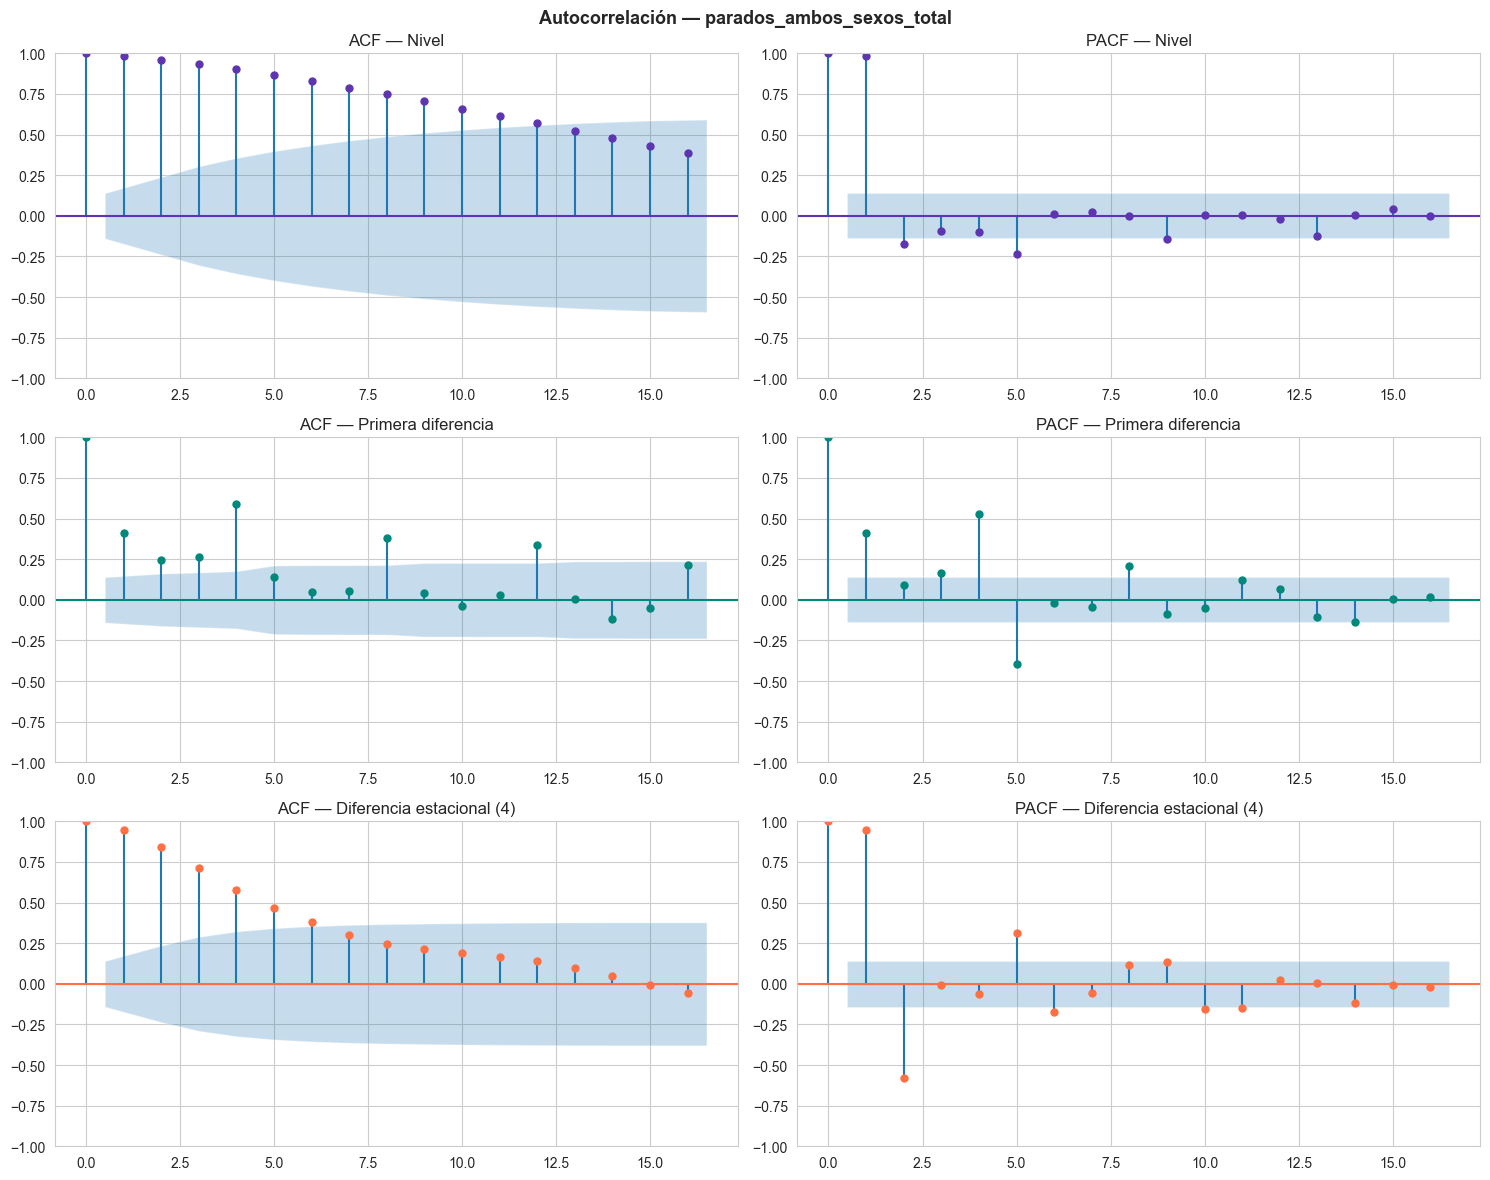

In [25]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle(f'Autocorrelación — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

plot_acf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 0], color=COLOR_PRINCIPAL,
         title='ACF — Nivel')
plot_pacf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 1], color=COLOR_PRINCIPAL,
          title='PACF — Nivel', method='ywm')
plot_acf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 0], color='#00897B',
         title='ACF — Primera diferencia')
plot_pacf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 1], color='#00897B',
          title='PACF — Primera diferencia', method='ywm')
plot_acf(diff_est.dropna(), lags=LAGS_ACF, ax=axes[2, 0], color='#FF7043',
         title=f'ACF — Diferencia estacional ({PERIODO_ESTACIONAL})')
plot_pacf(diff_est.dropna(), lags=LAGS_ACF, ax=axes[2, 1], color='#FF7043',
          title=f'PACF — Diferencia estacional ({PERIODO_ESTACIONAL})', method='ywm')

plt.tight_layout()
plt.show()

### Análisis:
- Serie en nivel: La Función de Autocorrelación (ACF) muestra un decaimiento extremadamente lento y prolongado. Esto constata visualmente que la serie es no estacionaria y posee una fuerte memoria larga, confirmando el diagnóstico previo del test KPSS.

- Diferencia respecto al trimestre anterior (diff 1): Aunque la tendencia general desaparece, el ACF exhibe picos estadísticamente significativos de forma periódica cada 4 retardos (lags 4, 8, 12). Esto evidencia empíricamente una fuerte estructura estacional determinista que esta transformación simple es incapaz de limpiar.

- Diferencia interanual (diff 4): Tras esta transformación, tanto el ACF como el PACF muestran una extinción rápida de las autocorrelaciones, que entran en las bandas de confianza de ruido blanco. Esto certifica gráficamente que la diferenciación interanual logra la estacionariedad completa, eliminando simultáneamente la tendencia estocástica y la estacionalidad intra-anual.

---
### Tasa de paro

In [26]:
# ── Tests de estacionariedad sobre la tasa de paro ────────────────────────
if 'tasa_paro_ambos_sexos_total' in df.columns:
    tasa = df['tasa_paro_ambos_sexos_total'].dropna()
    tasa_diff1 = tasa.diff().dropna()
    tasa_diff_est = tasa.diff(PERIODO_ESTACIONAL).dropna()

    series_test_tasa = [
        (tasa, 'Tasa de paro (nivel)', 'c'),
        (tasa_diff1, 'Tasa de paro (1ª diferencia)', 'c'),
        (tasa_diff_est, f'Tasa de paro (diff estacional {PERIODO_ESTACIONAL})', 'c'),
    ]
    resultados_tasa = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test_tasa])

    print('Tests de estacionariedad — TASA DE PARO')
    print('=' * 85)
    print(resultados_tasa.to_string(index=False))
    print()
    print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
    for _, row in resultados_tasa.iterrows():
        h0_adf = 'rechaza H₀' if row['ADF_H0_rechaza'] else 'NO rechaza H₀'
        h0_kpss = 'rechaza H₀' if row['KPSS_H0_rechaza'] else 'NO rechaza H₀'
        print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
        print(f"    ADF  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
        print(f"    KPSS stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
        print(f"    → {row['conclusion']}")
        print()


Tests de estacionariedad — TASA DE PARO
                           serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza   conclusion
            Tasa de paro (nivel)          c    -3.093  0.027            True      0.147   0.100            False ESTACIONARIA
    Tasa de paro (1ª diferencia)          c    -3.292  0.015            True      0.285   0.100            False ESTACIONARIA
Tasa de paro (diff estacional 4)          c    -3.265  0.017            True      0.245   0.100            False ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  Tasa de paro (nivel)  (KPSS regression='c')
    ADF  stat=-3.093, p=0.0271 (rechaza H₀)
    KPSS stat=0.147, p=0.1000 (NO rechaza H₀)
    → ESTACIONARIA

  Tasa de paro (1ª diferencia)  (KPSS regression='c')
    ADF  stat=-3.292, p=0.0153 (rechaza H₀)
    KPSS stat=0.285, p=0.1000 (NO rechaza H₀)
    → ESTACIONARIA

  Tasa de paro (diff estacional 4)  (KPSS regression='c')
    ADF  sta

### Análisis:
Tasa de paro (nivel): El test ADF rechaza la H₀ de raíz unitaria (p=0.027) y el KPSS no rechaza su H₀ de estacionariedad (p=0.100). Mecánicamente, la serie es estacionaria. Al ser una variable porcentual y acotada en un horizonte de 50 años, los tests detectan una reversión a su media histórica. Sin embargo, su altísima inercia estructural desaconseja por completo modelarla de forma cruda en niveles.

Tasa de paro (1ª diferencia): Ambos tests vuelven a converger en estacionariedad (ADF p=0.015, KPSS p=0.100). No obstante, aplicar una primera diferencia sobre una serie que estadísticamente ya es I(0) acarrea un severo riesgo de sobrediferenciación. Además, esta operación metodológicamente no resuelve el problema de la marcada estacionalidad de la EPA.

Tasa de paro (diff estacional 4): Ambos tests ratifican de nuevo la estacionariedad fuerte (ADF p=0.017, KPSS p=0.100). Esta es la transformación matemáticamente y macroeconómicamente correcta: respeta los contrastes, estabiliza el ciclo intra-anual y purga la inercia, siendo la variable definitiva a integrar en el modelado.

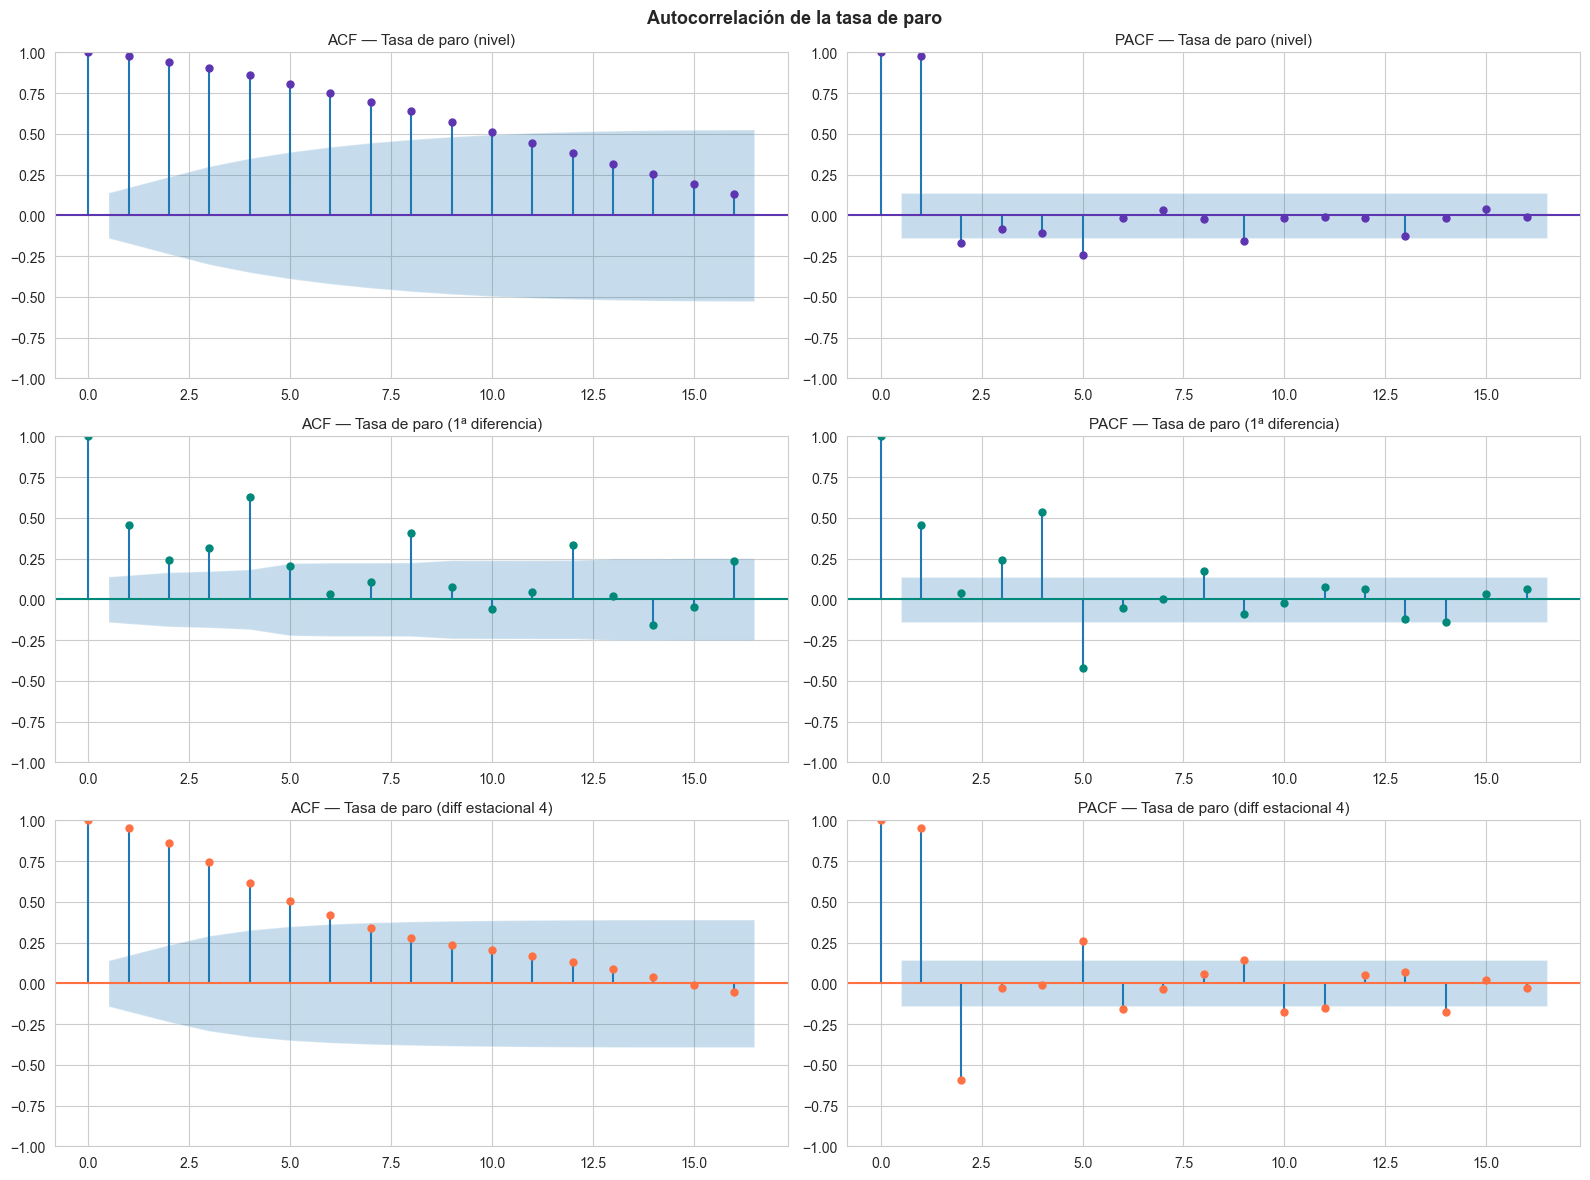

In [27]:
# ── ACF/PACF de la tasa de paro ───────────────────────────────────────────
if 'tasa_paro_ambos_sexos_total' in df.columns:
    tasa = df['tasa_paro_ambos_sexos_total'].dropna()
    tasa_diff = tasa.diff().dropna()
    tasa_diff_est = tasa.diff(PERIODO_ESTACIONAL).dropna()

    fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    fig.suptitle('Autocorrelación de la tasa de paro', fontsize=13, fontweight='bold')

    plot_acf(tasa, lags=LAGS_ACF, ax=axes[0, 0], color=COLOR_PRINCIPAL)
    axes[0, 0].set_title('ACF — Tasa de paro (nivel)', fontsize=11)

    plot_pacf(tasa, lags=LAGS_ACF, ax=axes[0, 1], color=COLOR_PRINCIPAL, method='ywm')
    axes[0, 1].set_title('PACF — Tasa de paro (nivel)', fontsize=11)

    plot_acf(tasa_diff, lags=LAGS_ACF, ax=axes[1, 0], color='#00897B')
    axes[1, 0].set_title('ACF — Tasa de paro (1ª diferencia)', fontsize=11)

    plot_pacf(tasa_diff, lags=LAGS_ACF, ax=axes[1, 1], color='#00897B', method='ywm')
    axes[1, 1].set_title('PACF — Tasa de paro (1ª diferencia)', fontsize=11)

    plot_acf(tasa_diff_est, lags=LAGS_ACF, ax=axes[2, 0], color='#FF7043')
    axes[2, 0].set_title(f'ACF — Tasa de paro (diff estacional {PERIODO_ESTACIONAL})', fontsize=11)

    plot_pacf(tasa_diff_est, lags=LAGS_ACF, ax=axes[2, 1], color='#FF7043', method='ywm')
    axes[2, 1].set_title(f'PACF — Tasa de paro (diff estacional {PERIODO_ESTACIONAL})', fontsize=11)

    plt.tight_layout()
    plt.show()

### Análisis:

- Serie en nivel: Contradiciendo el resultado aislado y engañoso de la tabla de tests, el ACF decae de forma muy lenta y sostenida, sin entrar en las bandas de confianza. Esto revela una fortísima dependencia temporal. A efectos de modelado predictivo, la serie se comporta como no estacionaria.

- Diferencia respecto al trimestre anterior (diff 1): El ACF presenta claros rebotes sistemáticos cada 4 periodos (lags 4, 8, 12). Esto demuestra gráficamente que el ciclo estacional de contratación y despido sigue intacto, contaminando la serie diferenciada e invalidándola para su uso.

- Diferencia interanual (diff estacional 4): Diferencia interanual (diff estacional 4): Tras esta transformación, el ACF muestra un decaimiento exponencial rápido que entra en las bandas de confianza a partir del lag 7-8, frente al decaimiento lineal interminable de la serie en niveles. El PACF presenta un único spike negativo significativo en lag 1 y corta limpiamente, patrón característico de un proceso AR(1) estacionario. La diferenciación interanual elimina con éxito tanto la inercia de largo plazo como la estacionalidad, dejando una estructura autorregresiva residual de bajo orden.

---
## 7. Variables Derivadas Intra-Dataset
Ratios y transformaciones calculadas a partir de las columnas de este dataset.

In [28]:
df_der = pd.DataFrame(index=df.index)

df_der['share_paro_juvenil'] = df['parados_ambos_sexos_menos_de_25'] / df['parados_ambos_sexos_total'] * 100
df_der['brecha_genero_parados'] = df['parados_mujeres_total'] - df['parados_hombres_total']
df_der['ratio_feminizacion_paro'] = df['parados_mujeres_total'] / df['parados_ambos_sexos_total'] * 100
df_der['indice_relativo_paro'] = df['parados_ambos_sexos_total'] / df['parados_ambos_sexos_total'].mean() * 100

print(f'Variables derivadas creadas ({len(df_der.columns)}):')
display(df_der.describe().round(3))

Variables derivadas creadas (4):


,share_paro_juvenil,brecha_genero_parados,ratio_feminizacion_paro,indice_relativo_paro
count,198.000,198.000,198.000,198.000
mean,29.967,-90.667,47.698,100.000
std,13.244,337.792,8.094,41.554
min,13.572,-884.408,28.913,20.218
25%,16.859,-373.528,45.356,75.599
50%,26.828,36.049,50.537,94.645
75%,42.881,188.425,53.283,115.247
max,54.849,343.452,57.947,215.504


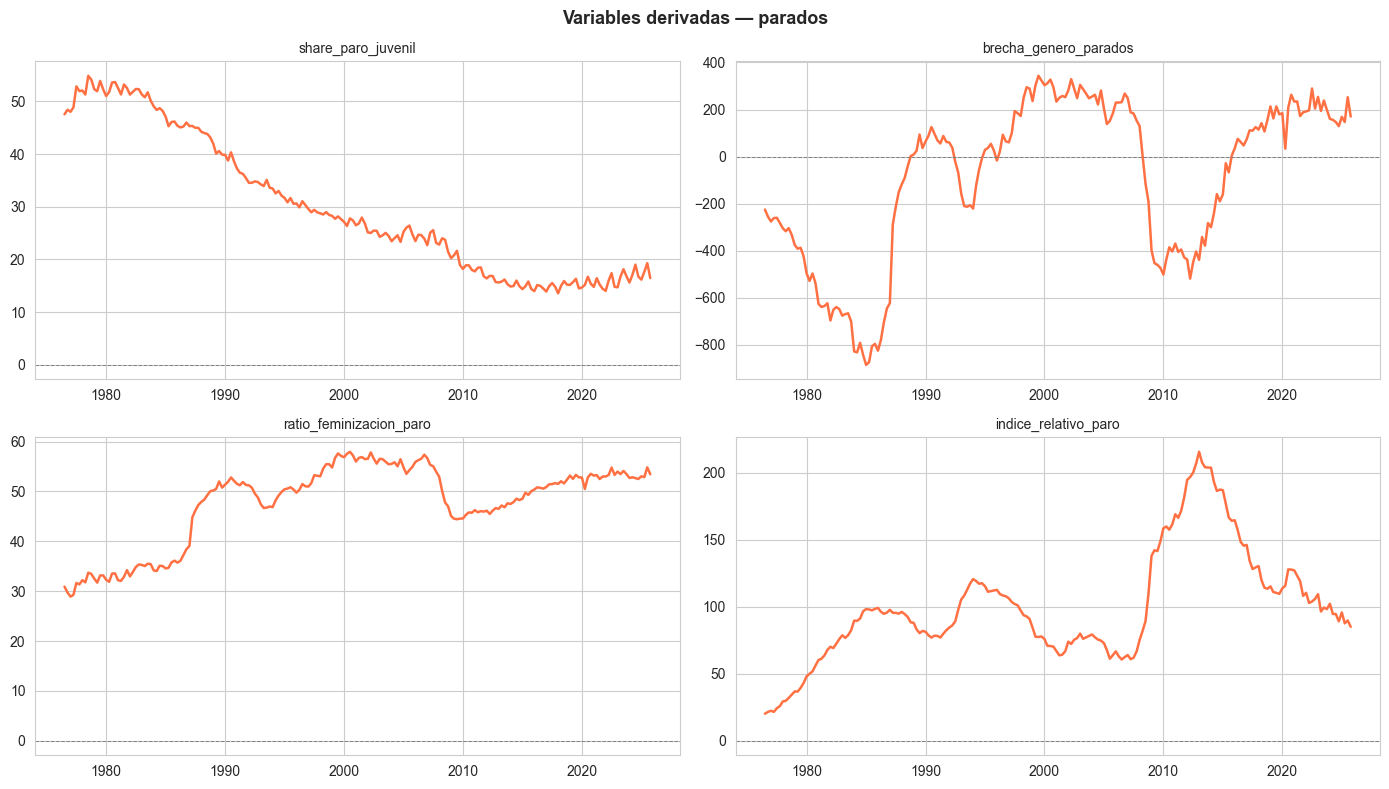

In [29]:
if not df_der.empty and len(df_der.columns) > 0:
    ncols = min(2, len(df_der.columns))
    nrows = (len(df_der.columns) + 1) // 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = np.array(axes).flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(f'Variables derivadas — {NOMBRE}', fontsize=13, fontweight='bold')

    for ax, col in zip(axes, df_der.columns):
        serie = df_der[col].dropna()
        ax.plot(serie.index, serie, color='#FF7043', lw=1.8)
        ax.axhline(0, color='gray', lw=0.7, linestyle='--')
        ax.set_title(col, fontsize=10)

    for ax in axes[len(df_der.columns):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

### Análisis:

Se construyen cuatro variables derivadas a partir de los componentes desagregados de la EPA, con el objetivo de capturar dimensiones estructurales del desempleo no recogidas por la tasa agregada.

- share_paro_juvenil: proporción de parados menores de 25 años sobre el total de parados. Presenta una tendencia estructural decreciente desde valores próximos al 55% en 1976 hasta estabilizarse en torno al 15-20% desde 2000, reflejo del envejecimiento progresivo de la población activa española. Los repuntes en 2008-2013 y 2020 son coherentes con la mayor sensibilidad del empleo juvenil a los ciclos recesivos.
- brecha_genero_parados: diferencia en valor absoluto entre parados masculinos y femeninos (en miles). La media negativa (−90.667) y la elevada desviación típica (337.792) reflejan un cambio estructural de signo: hasta mediados de los noventa predominaba el desempleo femenino (valores negativos), mientras que a partir de la crisis de 2008 el desempleo masculino supera al femenino de forma sostenida, fruto de la destrucción de empleo en sectores masculinizados como la construcción.
- ratio_feminizacion_paro: peso de las mujeres sobre el total de parados. Evoluciona desde valores del 30% en los setenta hasta estabilizarse en torno al 50-55% en la etapa reciente, con una reducción durante 2008-2013 por el mismo efecto sectorial descrito anteriormente.
- indice_relativo_paro: índice que normaliza el nivel de desempleo respecto a un periodo base (media = 100). Permite visualizar la magnitud relativa de cada ciclo: el pico de 2012-2013 alcanza valores superiores a 200, más del doble del nivel de referencia, mientras que el mínimo histórico se sitúa en torno a 20 en los años setenta.



In [30]:
# ── Guardar dataset enriquecido ───────────────────────────────────────────
if not df_der.empty:
    for col in df_der.columns:
        df[col] = df_der[col]
    df.to_csv(ruta)
    print(f'CSV sobreescrito: {ruta.name}')
    print(f'  {len(df_der.columns)} variables añadidas: {list(df_der.columns)}')
    print(f'  Columnas totales: {len(df.columns)}')
else:
    print('No se crearon variables derivadas.')

CSV sobreescrito: parados_sexo_edad.csv
  4 variables añadidas: ['share_paro_juvenil', 'brecha_genero_parados', 'ratio_feminizacion_paro', 'indice_relativo_paro']
  Columnas totales: 37


---
## 8. Tabla Resumen

In [31]:
est_nivel = resultados_est[resultados_est['serie'].str.contains('nivel')]['conclusion'].values[0]
est_diff1 = resultados_est[resultados_est['serie'].str.contains('diff 1')]['conclusion'].values[0]

if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):
    idx_max = indice_estacional.idxmax()
    idx_min = indice_estacional.idxmin()
else:
    idx_max = 'N/A'
    idx_min = 'N/A'

resumen = pd.DataFrame([{
    'Dataset':               NOMBRE,
    'Variable':              VAR_PRINCIPAL,
    'Frecuencia':            DATASET_CONFIG['frecuencia_original'],
    'Rango':                 f'{df.index.min().date()} — {df.index.max().date()}',
    'N obs':                 len(y.dropna()),
    'Media':                 y.mean().round(2),
    'Mediana':               y.median().round(2),
    'Std':                   y.std().round(2),
    'CV (%)':                (y.std() / y.mean() * 100).round(1),
    'Mín (fecha)':           f'{y.min():.1f} ({y.idxmin().date()})',
    'Máx (fecha)':           f'{y.max():.1f} ({y.idxmax().date()})',
    'Outliers IQR':          len(outliers_iqr),
    '% faltantes':           f'{df[VAR_PRINCIPAL].isnull().mean()*100:.1f}%',
    'Estacionaria (nivel)':  est_nivel,
    'Estacionaria (diff 1)': est_diff1,
    'Periodo más alto':      idx_max,
    'Periodo más bajo':      idx_min,
}]).T

resumen.columns = ['Valor']
print('=' * 60)
print('TABLA RESUMEN')
print('=' * 60)
print(resumen.to_string())

TABLA RESUMEN
                                           Valor
Dataset                                  parados
Variable               parados_ambos_sexos_total
Frecuencia                            trimestral
Rango                    1976-07-01 — 2025-10-01
N obs                                        198
Media                                   2913.270
Mediana                                 2757.250
Std                                     1210.590
CV (%)                                    41.600
Mín (fecha)                   589.0 (1976-07-01)
Máx (fecha)                  6278.2 (2013-01-01)
Outliers IQR                                  15
% faltantes                                 0.0%
Estacionaria (nivel)             NO ESTACIONARIA
Estacionaria (diff 1)            NO ESTACIONARIA
Periodo más alto                              T1
Periodo más bajo                              T3


---
### Tasa de paro

In [32]:
# ── Tabla resumen: Tasa de paro ───────────────────────────────────────────
if 'tasa_paro_ambos_sexos_total' in df.columns:
    tasa = df['tasa_paro_ambos_sexos_total'].dropna()

    est_nivel_t = resultados_tasa[resultados_tasa['serie'].str.contains('nivel')]['conclusion'].values[0]
    est_diff1_t = resultados_tasa[resultados_tasa['serie'].str.contains('1ª diferencia')]['conclusion'].values[0]

    if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):
        idx_max_t = indice_estacional_t.idxmax()
        idx_min_t = indice_estacional_t.idxmin()
    else:
        idx_max_t = 'N/A'
        idx_min_t = 'N/A'

    resumen_tasa = pd.DataFrame([{
        'Dataset':               NOMBRE,
        'Variable':              'tasa_paro_ambos_sexos_total',
        'Frecuencia':            DATASET_CONFIG['frecuencia_original'],
        'Rango':                 f'{df.index.min().date()} — {df.index.max().date()}',
        'N obs':                 len(tasa),
        'Media (%)':             tasa.mean().round(2),
        'Mediana (%)':           tasa.median().round(2),
        'Std (pp)':              tasa.std().round(2),
        'CV (%)':                (tasa.std() / tasa.mean() * 100).round(1),
        'Mín (fecha)':           f'{tasa.min():.2f}% ({tasa.idxmin().date()})',
        'Máx (fecha)':           f'{tasa.max():.2f}% ({tasa.idxmax().date()})',
        '% faltantes':           f'{df["tasa_paro_ambos_sexos_total"].isnull().mean()*100:.1f}%',
        'Estacionaria (nivel)':  est_nivel_t,
        'Estacionaria (diff 1)': est_diff1_t,
        'Periodo más alto':      idx_max_t,
        'Periodo más bajo':      idx_min_t,
    }]).T

    resumen_tasa.columns = ['Valor']
    print()
    print('=' * 60)
    print('TABLA RESUMEN — TASA DE PARO')
    print('=' * 60)
    print(resumen_tasa.to_string())


TABLA RESUMEN — TASA DE PARO
                                             Valor
Dataset                                    parados
Variable               tasa_paro_ambos_sexos_total
Frecuencia                              trimestral
Rango                      1976-07-01 — 2025-10-01
N obs                                          198
Media (%)                                   15.470
Mediana (%)                                 15.480
Std (pp)                                     5.060
CV (%)                                      32.700
Mín (fecha)                     4.41% (1976-07-01)
Máx (fecha)                    26.94% (2013-01-01)
% faltantes                                   0.0%
Estacionaria (nivel)                  ESTACIONARIA
Estacionaria (diff 1)                 ESTACIONARIA
Periodo más alto                                T1
Periodo más bajo                                T3


### Análisis y conclusiones:

Las dos tablas resumen confirman propiedades estadísticas distintas para cada serie. `parados_ambos_sexos_total`, expresada en miles de personas, es no estacionaria en niveles y Las dos tablas resumen confirman propiedades estadísticas distintas para cada serie. parados_ambos_sexos_total, expresada en miles de personas, es no estacionaria en niveles y en primera diferencia, alcanzando estacionariedad únicamente tras la diferenciación interanual. Este comportamiento indica la presencia de una raíz unitaria con componente estacional: los shocks sobre el desempleo absoluto se acumulan a lo largo del periodo muestral (589.000 en 1976-T3; 6.278.200 en 2013-T1), sin reversión espontánea a la media.

La tasa de paro, `tasa_paro_ambos_sexos_total`, presenta propiedades radicalmente distintas: ADF y KPSS coinciden en clasificarla como estacionaria ya en niveles (ADF p = 0,027; KPSS p = 0,100), con una media del 15,47% y una mediana de 15,48% que evidencian reversión a la media a lo largo del ciclo. Su coeficiente de variación (32,7%) es significativamente inferior al de la serie absoluta (41,6%), lo que refleja una mayor estabilidad relativa. No es contradictorio que la serie absoluta sea no estacionaria y su tasa sí lo sea: al dividir por la población activa se elimina la componente de escala que genera la raíz unitaria, y es un resultado habitual en series macroeconómicas. No obstante, el p-valor de ADF (0,027) es borderline y el ACF en niveles muestra un decaimiento muy lento, compatible con un proceso cercano a la raíz unitaria. Por ello, la modelización adoptará la diferenciación interanual como transformación principal, que los correlogramas confirman como la única que elimina simultáneamente la inercia y la estacionalidad.

Por tanto, la tasa de paro es la variable objetivo del modelo, tanto por sus propiedades estadísticas más favorables como por su interpretabilidad económica y su uso como indicador de referencia institucional.

El pipeline de modelización se bifurcará en función de la arquitectura de cada modelo:

- Prophet: consume la serie en niveles sin transformar, ya que modela explícitamente tendencia, estacionalidad y changepoints a partir de la serie bruta.
- ARIMA/SARIMAX: sin diferenciación regular, con diferenciación estacional interanual (cada observación menos la del mismo trimestre del año anterior), coherente con el diagnóstico ACF/PACF que muestra estructura limpia únicamente tras esta transformación.
- VAR: serie en niveles; las variables exógenas no estacionarias se diferencian previamente para garantizar estacionariedad conjunta del sistema.
- ML (Ridge, Lasso, RF, XGBoost): serie en niveles aprovechando su estacionariedad, con diferenciación interanual de las variables exógenas no estacionarias según lo requiera el análisis de features.